# Data Preparation


In [1]:
import os
import platform

IS_APPLE_SILICON = platform.system() == "Darwin" and platform.machine().lower() in {"arm64", "aarch64"}
if IS_APPLE_SILICON:
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")
    os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
    os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import helper_functions as hf
import constants as const

from pathlib import Path

from IPython.display import Image, display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

from constants import SVR_BASE_FEATURES, MODEL_SERIES_CAP_FALLBACK

MAX_LAG = const.MAX_LAG
MIN_OBS = const.MIN_OBS
ALPHA = const.ALPHA
SHORTLIST_MIN_OVERLAP = const.SHORTLIST_MIN_OVERLAP
TRANSFORM_MODES = const.TRANSFORM_MODES
GLOBAL_DRIVER_MIN_SHORTLISTED_SERIES = const.GLOBAL_DRIVER_MIN_SHORTLISTED_SERIES

MODEL_SERIES_CAP = const.MODEL_SERIES_CAP
MDOEL_SERIES_CAP_FALLBACK = const.MODEL_SERIES_CAP_FALLBACK
TARGET_COL = const.TARGET_COL
TARGET_LABEL = const.TARGET_LABEL
MIN_TRAIN_TARGET_ROWS = const.MIN_TRAIN_TARGET_ROWS
FORECAST_HORIZON = const.FORECAST_HORIZON
ROLLING_STEP = const.ROLLING_STEP
SEASONAL_PERIOD = const.SEASONAL_PERIOD

HOLDOUT_RATIO = const.HOLDOUT_RATIO
MIN_TRAIN_OBS_SARIMA = const.MIN_TRAIN_OBS_SARIMA
INNER_FOLDS_SARIMA = const.INNER_FOLDS_SARIMA
SARIMA_P_VALUES = const.SARIMA_P_VALUES
SARIMA_Q_VALUES = const.SARIMA_Q_VALUES
SARIMA_P_SEASONAL_VALUES = const.SARIMA_P_SEASONAL_VALUES
SARIMA_Q_SEASONAL_VALUES = const.SARIMA_Q_SEASONAL_VALUES
SARIMA_TREND_VALUES = const.SARIMA_TREND_VALUES
SARIMA_MAXITER = const.SARIMA_MAXITER
SARIMA_N_JOBS = const.SARIMA_N_JOBS

SVR_BASE_FEATURES = const.SVR_BASE_FEATURES
SVR_PARAM_GRID = const.SVR_PARAM_GRID

LIGHTGBM_BASE_FEATURES = const.LIGHTGBM_BASE_FEATURES
LIGHTGBM_TRIALS = const.LIGHTGBM_TRIALS
LIGHTGBM_RANDOM_STATE = const.LIGHTGBM_RANDOM_STATE

RUNTIME_CONFIG = hf.get_runtime_config(SARIMA_N_JOBS)
SARIMA_N_JOBS = RUNTIME_CONFIG["sarima_n_jobs"]
SKLEARN_N_JOBS = RUNTIME_CONFIG["sklearn_n_jobs"]
LIGHTGBM_N_JOBS = RUNTIME_CONFIG["lightgbm_n_jobs"]
hf.log_progress(
    f"Runtime config: system={RUNTIME_CONFIG['system']}, machine={RUNTIME_CONFIG['machine']}, "
    f"cpu_total={RUNTIME_CONFIG['cpu_total']}, sarima_jobs={SARIMA_N_JOBS}, "
    f"sklearn_jobs={SKLEARN_N_JOBS}, lightgbm_jobs={LIGHTGBM_N_JOBS}"
)


def display_saved_images(*paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            display(Image(filename=str(path)))


C:\Users\Utarou\Documents\THESIS FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Main Dataset


In [2]:
df_main = pd.read_csv("data/main/Combined Main Dataset.csv", low_memory=False)
df_main["month"] = pd.to_datetime(df_main["month"], errors="coerce")
df_main["price"] = pd.to_numeric(df_main["price"], errors="coerce")
display(df_main.head())


,month,region,commodity_name,price,source
0,2000-01-01,NCR,MAIZE FLOUR (YELLOW),15.00,food_prices
1,2000-01-01,NCR,MEAT (PORK),105.37,food_prices
2,2000-01-01,NCR,RICE (MILLED SUPERIOR),20.00,food_prices
3,2000-01-01,NCR,RICE (REGULAR MILLED),18.00,food_prices
4,2000-01-01,REGION III,MEAT (PORK),77.00,food_prices


## Exogenous Dataset


In [3]:
ex_diesel_raw = pd.read_csv("data/exogenous/Diesel Price.csv")
ex_food_index_raw = pd.read_csv("data/exogenous/Monthly food price estimates by product and market (2007-2025).csv")
ex_weather_1 = pd.read_csv("data/exogenous/philippines_weather_cdd_r50mm_hd35_monthly_2000-2023.csv")
ex_weather_2 = pd.read_csv("data/exogenous/philippines_weather_era5_monthly_2000-2023.csv")
ex_weather_raw = ex_weather_1.drop(columns=["DaysRainAbove50mm"]).merge(
    ex_weather_2,
    on="Date",
    how="inner"
)

ex_diesel_monthly = ex_diesel_raw.copy()
ex_diesel_monthly["month"] = pd.to_datetime(ex_diesel_monthly["Month"], format="%y-%b", errors="coerce")
ex_diesel_monthly["month"] = ex_diesel_monthly["month"].dt.to_period("M").dt.to_timestamp()
ex_diesel_monthly["diesel_price"] = pd.to_numeric(ex_diesel_monthly["Price"], errors="coerce")
ex_diesel_monthly = ex_diesel_monthly[["month", "diesel_price"]].dropna().sort_values("month").reset_index(drop=True)

ex_food_index = ex_food_index_raw.copy()
ex_food_index = ex_food_index[ex_food_index["Product"].astype(str).str.strip().str.lower() == "food_price_index"].copy()
ex_food_index["month"] = pd.to_datetime(ex_food_index["Date"], errors="coerce")
ex_food_index["month"] = ex_food_index["month"].dt.to_period("M").dt.to_timestamp()
ex_food_index["food_price_index"] = pd.to_numeric(ex_food_index["Close"], errors="coerce")
ex_food_index = (ex_food_index[["month", "food_price_index"]].dropna().groupby("month", as_index=False)["food_price_index"].mean().sort_values("month").reset_index(drop=True))

ex_weather_monthly = ex_weather_raw.copy()
ex_weather_monthly["month"] = pd.to_datetime(ex_weather_monthly["Date"], errors="coerce")
ex_weather_monthly = ex_weather_monthly.rename(
    columns={
        "MaxConsecutiveDryDays": "max_consecutive_dry_days",
        "DaysMaxTempAbove35C": "days_above_35c",
        "DaysRainAbove50mm": "days_rain_above_50mm_extreme",
        "Precipitation_mm": "precipitation_mm",
        "AvgMeanTemp_C": "avg_mean_temp_c",
    }
)
ex_weather_monthly = ex_weather_monthly.drop(columns=["Date"])

macro_external_monthly = (
    ex_diesel_monthly
    .merge(ex_food_index, on="month", how="outer")
    .merge(ex_weather_monthly, on="month", how="outer")
    .sort_values("month")
    .groupby("month", as_index=False).mean(numeric_only=True)
    .reset_index(drop=True)
)
macro_external_monthly = macro_external_monthly.dropna(subset=macro_external_monthly.columns.difference(["month"]))

display(macro_external_monthly.head())

,month,diesel_price,food_price_index,max_consecutive_dry_days,days_above_35c,precipitation_mm,days_rain_above_50mm_extreme,avg_mean_temp_c
128,2010-09-01,95.75,0.82,1.24,0.18,267.17,0.18,26.51
129,2010-10-01,100.01,0.80,1.59,0.09,319.79,0.40,26.10
130,2010-11-01,102.59,0.80,1.21,0.07,257.31,0.37,25.80
131,2010-12-01,109.67,0.83,2.69,0.04,230.10,0.26,25.27
132,2011-01-01,116.70,0.83,2.65,0.00,305.76,0.84,24.40


## Granger Causality


In [4]:
# 1.1. Granger Causality Test
commodity_granger_monthly = (
    df_main.groupby(["commodity_name", "month"], as_index=False)
    .agg(price=("price", "median"))
    .sort_values(["commodity_name", "month"])
    .reset_index(drop=True)
)
commodity_granger_monthly["source"] = "combined_main"

driver_columns = [
    "diesel_price",
    "food_price_index",
    "max_consecutive_dry_days",
    "days_above_35c",
    "precipitation_mm",
    "days_rain_above_50mm_extreme",
    "avg_mean_temp_c",
]

granger_result_frames = []
for transform_mode in TRANSFORM_MODES:
    transform_rows = []

    for driver_name in driver_columns:
        external_series = hf.transform_series(
            macro_external_monthly.set_index("month")[driver_name].sort_index(),
            transform_mode
        )
        external_adf_p = hf.safe_adf_pvalue(external_series)

        for commodity_name, group in commodity_granger_monthly.groupby("commodity_name"):
            commodity_series = group.set_index("month")["price"].sort_index()
            transformed_commodity = hf.transform_series(commodity_series, transform_mode)
            commodity_adf_p = hf.safe_adf_pvalue(transformed_commodity)

            forward = hf.run_granger_direction(
                transformed_commodity,
                external_series,
                max_lag=MAX_LAG,
                min_obs=MIN_OBS,
                alpha=ALPHA
            )

            reverse = hf.run_granger_direction(
                external_series,
                transformed_commodity,
                max_lag=MAX_LAG,
                min_obs=MIN_OBS,
                alpha=ALPHA
            )

            transform_rows.append({
                "source": "combined_main",
                "commodity_name": commodity_name,
                "transform_mode": transform_mode,
                "driver_name": driver_name,
                "commodity_adf_p": commodity_adf_p,
                "external_adf_p": external_adf_p,
                "forward_overlap_points": forward["overlap_points"],
                "forward_best_lag": forward["best_lag"],
                "forward_min_p_value": forward["min_p_value"],
                "forward_significant": forward["significant"],
                "forward_status": forward["status"],
                "reverse_best_lag": reverse["best_lag"],
                "reverse_min_p_value": reverse["min_p_value"],
                "reverse_significant": reverse["significant"],
                "reverse_status": reverse["status"],
            })

    transform_df = pd.DataFrame(transform_rows)
    transform_df["forward_bh_p_value"] = np.nan
    transform_df["reverse_bh_p_value"] = np.nan

    for driver_name in driver_columns:
        mask = transform_df["driver_name"] == driver_name
        transform_df.loc[mask, "forward_bh_p_value"] = hf.benjamini_hochberg(transform_df.loc[mask, "forward_min_p_value"])
        transform_df.loc[mask, "reverse_bh_p_value"] = hf.benjamini_hochberg(transform_df.loc[mask, "reverse_min_p_value"])

    transform_df["forward_significant_bh"] = transform_df["forward_bh_p_value"] < ALPHA
    transform_df["reverse_significant_bh"] = transform_df["reverse_bh_p_value"] < ALPHA

    transform_df["shortlist_candidate"] = (
            transform_df["forward_significant_bh"].fillna(False)
            & (~transform_df["reverse_significant_bh"].fillna(False))
            & (transform_df["forward_overlap_points"] >= SHORTLIST_MIN_OVERLAP)
    )

    granger_result_frames.append(transform_df)

granger_results_all = pd.concat(granger_result_frames, ignore_index=True)

granger_overview = (
    granger_results_all.groupby(["transform_mode", "driver_name"], as_index=False)
    .agg(
        series_tested=("commodity_name", "count"),
        raw_significant_forward=("forward_significant", lambda s: int(pd.Series(s).fillna(False).sum())),
        bh_significant_forward=("forward_significant_bh", lambda s: int(pd.Series(s).fillna(False).sum())),
        shortlist_candidate=("shortlist_candidate", lambda s: int(pd.Series(s).fillna(False).sum())),
    )
    .sort_values(["transform_mode", "driver_name"])
    .reset_index(drop=True)
)

global_driver_shortlist = (
    granger_results_all.loc[granger_results_all["shortlist_candidate"].fillna(False)]
    .groupby("driver_name", as_index=False)
    .agg(
        shortlisted_series=("commodity_name", "count"),
        transform_modes=("transform_mode",
                         lambda s: ", ".join(sorted(pd.Series(s).dropna().astype(str).unique()))),
        modal_best_lag=("forward_best_lag",
                        lambda s: int(pd.Series(s).dropna().mode().iloc[0]) if not pd.Series(
                            s).dropna().empty else 1),
        median_bh_p_value=("forward_bh_p_value", "median"),
    )
    .sort_values(["shortlisted_series", "median_bh_p_value"], ascending=[False, True])
    .reset_index(drop=True)
)

if global_driver_shortlist.empty:
    global_shortlisted_driver_lags = {}
else:
    selected_driver_rows = global_driver_shortlist.loc[
        global_driver_shortlist["shortlisted_series"] >= GLOBAL_DRIVER_MIN_SHORTLISTED_SERIES
    ].copy()
    if selected_driver_rows.empty:
        selected_driver_rows = global_driver_shortlist.head(min(3, len(global_driver_shortlist))).copy()
    global_shortlisted_driver_lags = {
        row["driver_name"]: int(max(1, min(MAX_LAG, row["modal_best_lag"])))
        for _, row in selected_driver_rows.iterrows()
    }

global_shortlisted_driver_table = pd.DataFrame(
    [
        {
            "driver_name": driver_name,
            "selected_lag": lag_value,
        }
        for driver_name, lag_value in global_shortlisted_driver_lags.items()
    ]
)

display(granger_overview)
display(global_driver_shortlist)
display(global_shortlisted_driver_table)


,transform_mode,driver_name,series_tested,raw_significant_forward,bh_significant_forward,shortlist_candidate
0,diff,avg_mean_temp_c,168,64,34,27
1,diff,days_above_35c,168,34,21,13
2,diff,days_rain_above_50mm_extreme,168,64,40,33
3,diff,diesel_price,168,33,7,6
4,diff,food_price_index,168,70,44,24
5,diff,max_consecutive_dry_days,168,24,1,0
6,diff,precipitation_mm,168,46,13,7
7,mom_pct,avg_mean_temp_c,168,64,36,30
8,mom_pct,days_above_35c,168,41,3,2
9,mom_pct,days_rain_above_50mm_extreme,168,21,3,2


,driver_name,shortlisted_series,transform_modes,modal_best_lag,median_bh_p_value
0,avg_mean_temp_c,57,"diff, mom_pct",1,0.031053
1,food_price_index,38,"diff, mom_pct",3,0.033677
2,days_rain_above_50mm_extreme,35,"diff, mom_pct",1,0.030906
3,days_above_35c,15,"diff, mom_pct",6,0.035280
4,max_consecutive_dry_days,13,mom_pct,3,0.039564
5,precipitation_mm,9,"diff, mom_pct",1,0.011620
6,diesel_price,6,diff,4,0.003360


,driver_name,selected_lag
0,avg_mean_temp_c,1
1,food_price_index,3
2,days_rain_above_50mm_extreme,1
3,days_above_35c,6
4,max_consecutive_dry_days,3
5,precipitation_mm,1


## Feature Engineering


In [5]:
# 1.2. Filter Valid Entries
valid_series = []
for (region, commodity_name), group in df_main.groupby(["region", "commodity_name"]):
    interpolated = hf.apply_linear_interpolation(group, max_gap=2)

    if interpolated is None:
        continue

    if len(interpolated) >= 36:
        interpolated["region"] = region
        interpolated["commodity_name"] = commodity_name
        valid_series.append(interpolated)

df_main_filtered = pd.concat(valid_series, ignore_index=True)
df_main_filtered = df_main_filtered.sort_values(
    ["region", "commodity_name", "month"]
).reset_index(drop=True)

# 1.3. Feature Engineering
df_main_filtered = df_main_filtered.merge(
    macro_external_monthly,
    on="month",
    how="left"
)

regional_panel = df_main_filtered.copy()

regional_preprocessed_full = hf.add_basic_price_features(regional_panel)

regional_preprocessed_full, regional_exogenous_feature_columns = hf.add_exogenous_lags(
    regional_preprocessed_full,
    drivers=[
        "diesel_price",
        "food_price_index",
        "max_consecutive_dry_days",
        "days_above_35c",
        "days_rain_above_50mm_extreme",
        "precipitation_mm",
        "avg_mean_temp_c",
    ]
)

global_exogenous_feature_columns = regional_exogenous_feature_columns.copy()
regional_series_manifest, regional_preprocessed_panel = hf.build_series_manifest(regional_preprocessed_full)

all_eligible_series_manifest = regional_series_manifest.copy()

if len(all_eligible_series_manifest) >= MODEL_SERIES_CAP:
    modeling_series_cap = MODEL_SERIES_CAP
elif len(all_eligible_series_manifest) >= MODEL_SERIES_CAP_FALLBACK:
    modeling_series_cap = MODEL_SERIES_CAP_FALLBACK
else:
    modeling_series_cap = len(all_eligible_series_manifest)

eligible_series_manifest = (
    hf.select_series_manifest_balanced(
        all_eligible_series_manifest,
        modeling_series_cap,
        group_col="region",
    )
)

eligible_series_ids = set(eligible_series_manifest["series_id"])

eligible_panel = regional_preprocessed_panel.loc[
    regional_preprocessed_panel["series_id"].isin(eligible_series_ids)
].copy()

eligibility_overview = pd.DataFrame(
    [
        {
            "all_series": regional_series_manifest["series_id"].nunique(),
            "selected_series_for_modeling": eligible_series_manifest["series_id"].nunique(),
            "selection_cap": modeling_series_cap,
            "selection_strategy": "balanced_by_region_with_global_fill" if modeling_series_cap < len(all_eligible_series_manifest) else "full_manifest",
            "eligible_panel_rows": len(eligible_panel),
            "eligible_unique_commodities": eligible_panel["commodity_name"].nunique(),
            "all_regions": regional_series_manifest["region"].nunique(),
            "eligible_regions": eligible_panel["region"].nunique(),
            "region_coverage_pct": float(
                (eligible_panel["region"].nunique() / regional_series_manifest["region"].nunique()) * 100
            ) if regional_series_manifest["region"].nunique() else np.nan,
        }
    ]
)


target_ready_panel = eligible_panel.loc[eligible_panel[TARGET_COL].notna()].copy()

split_readiness = (
    target_ready_panel.groupby("series_id")
    .agg(
        region=("region", "first"),
        commodity_name=("commodity_name", "first"),
        target_rows=(TARGET_COL, "size"),
        first_target_month=("month", "min"),
        last_target_month=("month", "max"),
    )
    .reset_index()
)

split_readiness["walk_forward_ready"] = (
    split_readiness["target_rows"] >= (MIN_TRAIN_TARGET_ROWS + FORECAST_HORIZON)
)

evaluation_setup = pd.DataFrame(
    [
        {
            "target_column": TARGET_COL,
            "minimum_training_rows": MIN_TRAIN_TARGET_ROWS,
            "forecast_horizon": FORECAST_HORIZON,
            "rolling_step": ROLLING_STEP,
            "seasonal_period": SEASONAL_PERIOD,
            "walk_forward_ready_series": int(split_readiness["walk_forward_ready"].sum()),
        }
    ]
)

display(eligibility_overview)
display(eligible_series_manifest.head(10))
display(evaluation_setup)
display(split_readiness.head(10))


,all_series,selected_series_for_modeling,selection_cap,selection_strategy,eligible_panel_rows,eligible_unique_commodities,all_regions,eligible_regions,region_coverage_pct
0,1194,100,100,balanced_by_region_with_global_fill,6000,25,17,17,100.0


,series_id,region,commodity_name,start_month,end_month,months_total,price_rows,mom_rows,yoy_rows,eligible,selection_global_rank,selection_group_rank,selection_stage,selection_rank
0,ARMM|ALOY/TULINGAN,ARMM,ALOY/TULINGAN,2021-01-01,2025-12-01,60,60,60,60,True,1,1,group_quota,1
1,ARMM|AVOCADO,ARMM,AVOCADO,2021-01-01,2025-12-01,60,60,60,60,True,2,2,group_quota,2
2,ARMM|BANANA,ARMM,BANANA,2021-01-01,2025-12-01,60,60,60,60,True,3,3,group_quota,3
3,ARMM|BEEF,ARMM,BEEF,2021-01-01,2025-12-01,60,60,60,60,True,4,4,group_quota,4
4,ARMM|BIG-EYED SCAD,ARMM,BIG-EYED SCAD,2021-01-01,2025-12-01,60,60,60,60,True,5,5,group_quota,5
5,ARMM|BITTER GOURD (AMPALAYA),ARMM,BITTER GOURD (AMPALAYA),2021-01-01,2025-12-01,60,60,60,60,True,6,6,global_fill,6
6,ARMM|CALAMANSI,ARMM,CALAMANSI,2021-01-01,2025-12-01,60,60,60,60,True,7,7,global_fill,7
7,ARMM|CARABEEF,ARMM,CARABEEF,2021-01-01,2025-12-01,60,60,60,60,True,8,8,global_fill,8
8,ARMM|CARROT,ARMM,CARROT,2021-01-01,2025-12-01,60,60,60,60,True,9,9,global_fill,9
9,ARMM|CASSAVA (KAMOTENG KAHOY),ARMM,CASSAVA (KAMOTENG KAHOY),2021-01-01,2025-12-01,60,60,60,60,True,10,10,global_fill,10


,target_column,minimum_training_rows,forecast_horizon,rolling_step,seasonal_period,walk_forward_ready_series
0,yoy_inflation,24,1,1,12,100


,series_id,region,commodity_name,target_rows,first_target_month,last_target_month,walk_forward_ready
0,ARMM|ALOY/TULINGAN,ARMM,ALOY/TULINGAN,60,2021-01-01,2025-12-01,True
1,ARMM|AVOCADO,ARMM,AVOCADO,60,2021-01-01,2025-12-01,True
2,ARMM|BANANA,ARMM,BANANA,60,2021-01-01,2025-12-01,True
3,ARMM|BEEF,ARMM,BEEF,60,2021-01-01,2025-12-01,True
4,ARMM|BIG-EYED SCAD,ARMM,BIG-EYED SCAD,60,2021-01-01,2025-12-01,True
5,ARMM|BITTER GOURD (AMPALAYA),ARMM,BITTER GOURD (AMPALAYA),60,2021-01-01,2025-12-01,True
6,ARMM|CALAMANSI,ARMM,CALAMANSI,60,2021-01-01,2025-12-01,True
7,ARMM|CARABEEF,ARMM,CARABEEF,60,2021-01-01,2025-12-01,True
8,ARMM|CARROT,ARMM,CARROT,60,2021-01-01,2025-12-01,True
9,ARMM|CASSAVA (KAMOTENG KAHOY),ARMM,CASSAVA (KAMOTENG KAHOY),60,2021-01-01,2025-12-01,True


## Stationarity and Seasonality


,series_tested,stationary_at_5pct_aic,stationary_at_5pct_bic,recommend_d_0,recommend_d_1
0,100,47,38,33,67


,series_checked,strong_lag12_signal,recommend_D_0,recommend_D_1
0,100,68,32,68


,series_id,region,commodity_name,lag12_autocorr,month_profile_std,recommended_D
0,REGION IV-A|BEEF,REGION IV-A,BEEF,0.612253,0.610434,1
1,REGION II|BANANA,REGION II,BANANA,0.592417,1.577791,1
2,REGION VII|BANANA,REGION VII,BANANA,0.352706,1.650090,1
3,NCR|BEEF,NCR,BEEF,0.333514,0.573260,1
4,ARMM|CORN GRITS,ARMM,CORN GRITS,0.318914,1.666351,1
5,REGION V|BEEF,REGION V,BEEF,0.277096,0.362851,1
6,REGION I|BEEF,REGION I,BEEF,0.265503,0.257553,1
7,REGION I|AVOCADO,REGION I,AVOCADO,0.261581,3.303905,1
8,REGION II|BEEF,REGION II,BEEF,0.235209,0.637660,1
9,ARMM|CARROT,ARMM,CARROT,-0.209935,1.252768,1


,selected_target,eligible_series,walk_forward_ready_series,median_target_rows,median_series_length
0,yoy_inflation,100,100,60.0,60.0


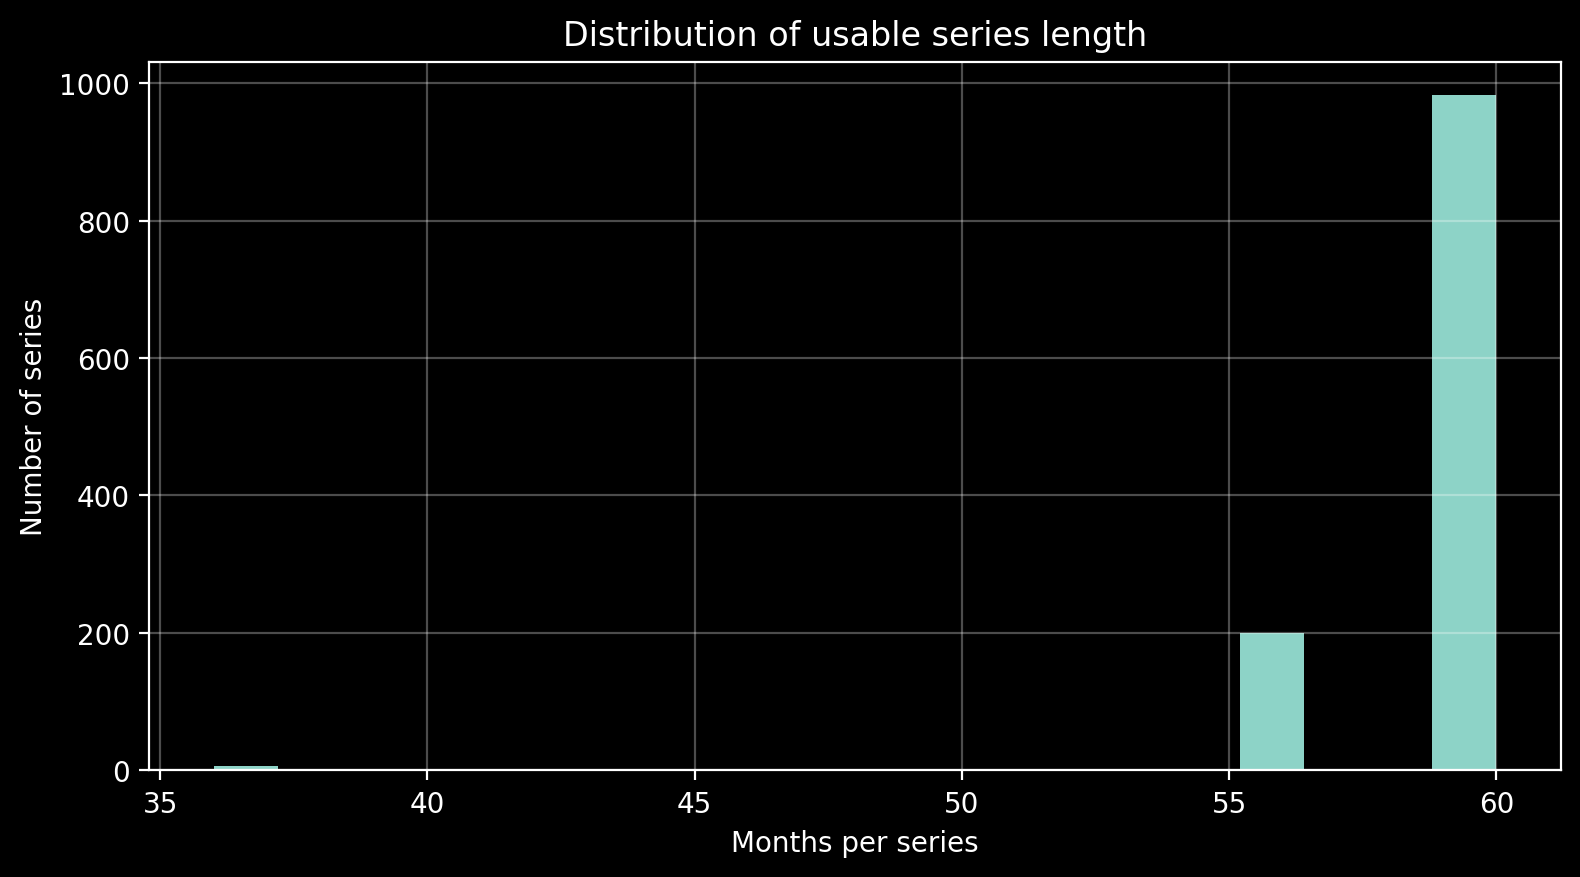

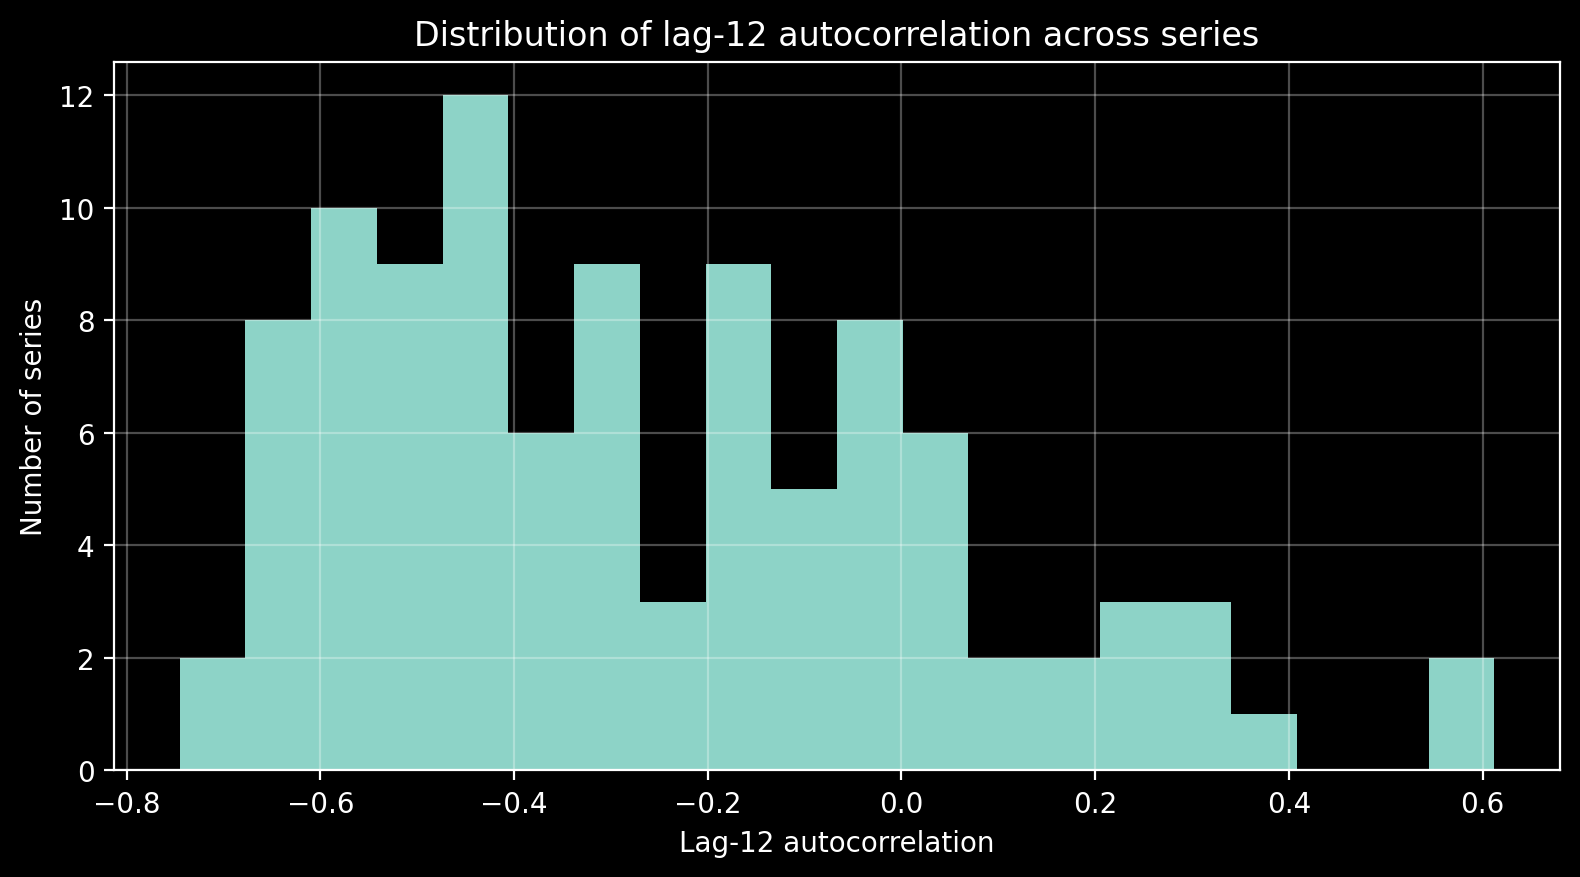

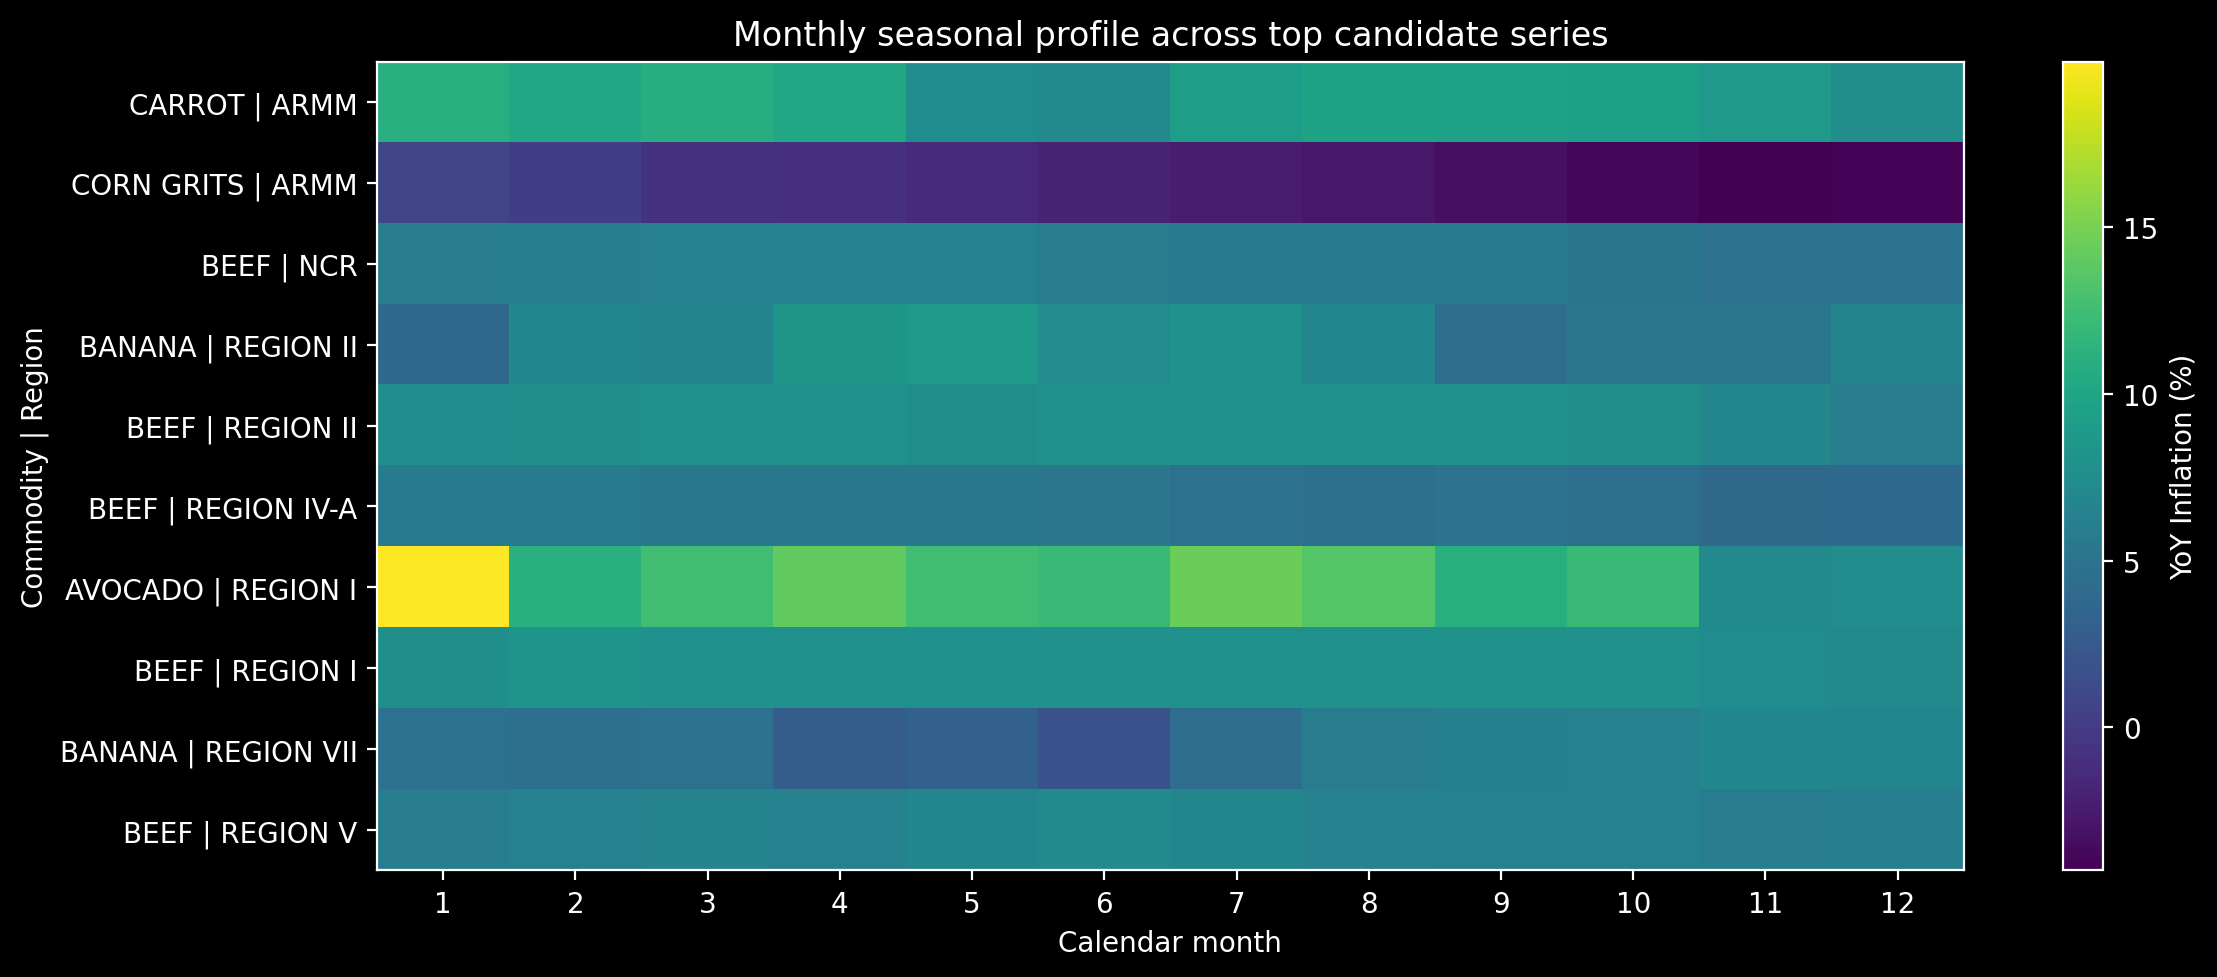

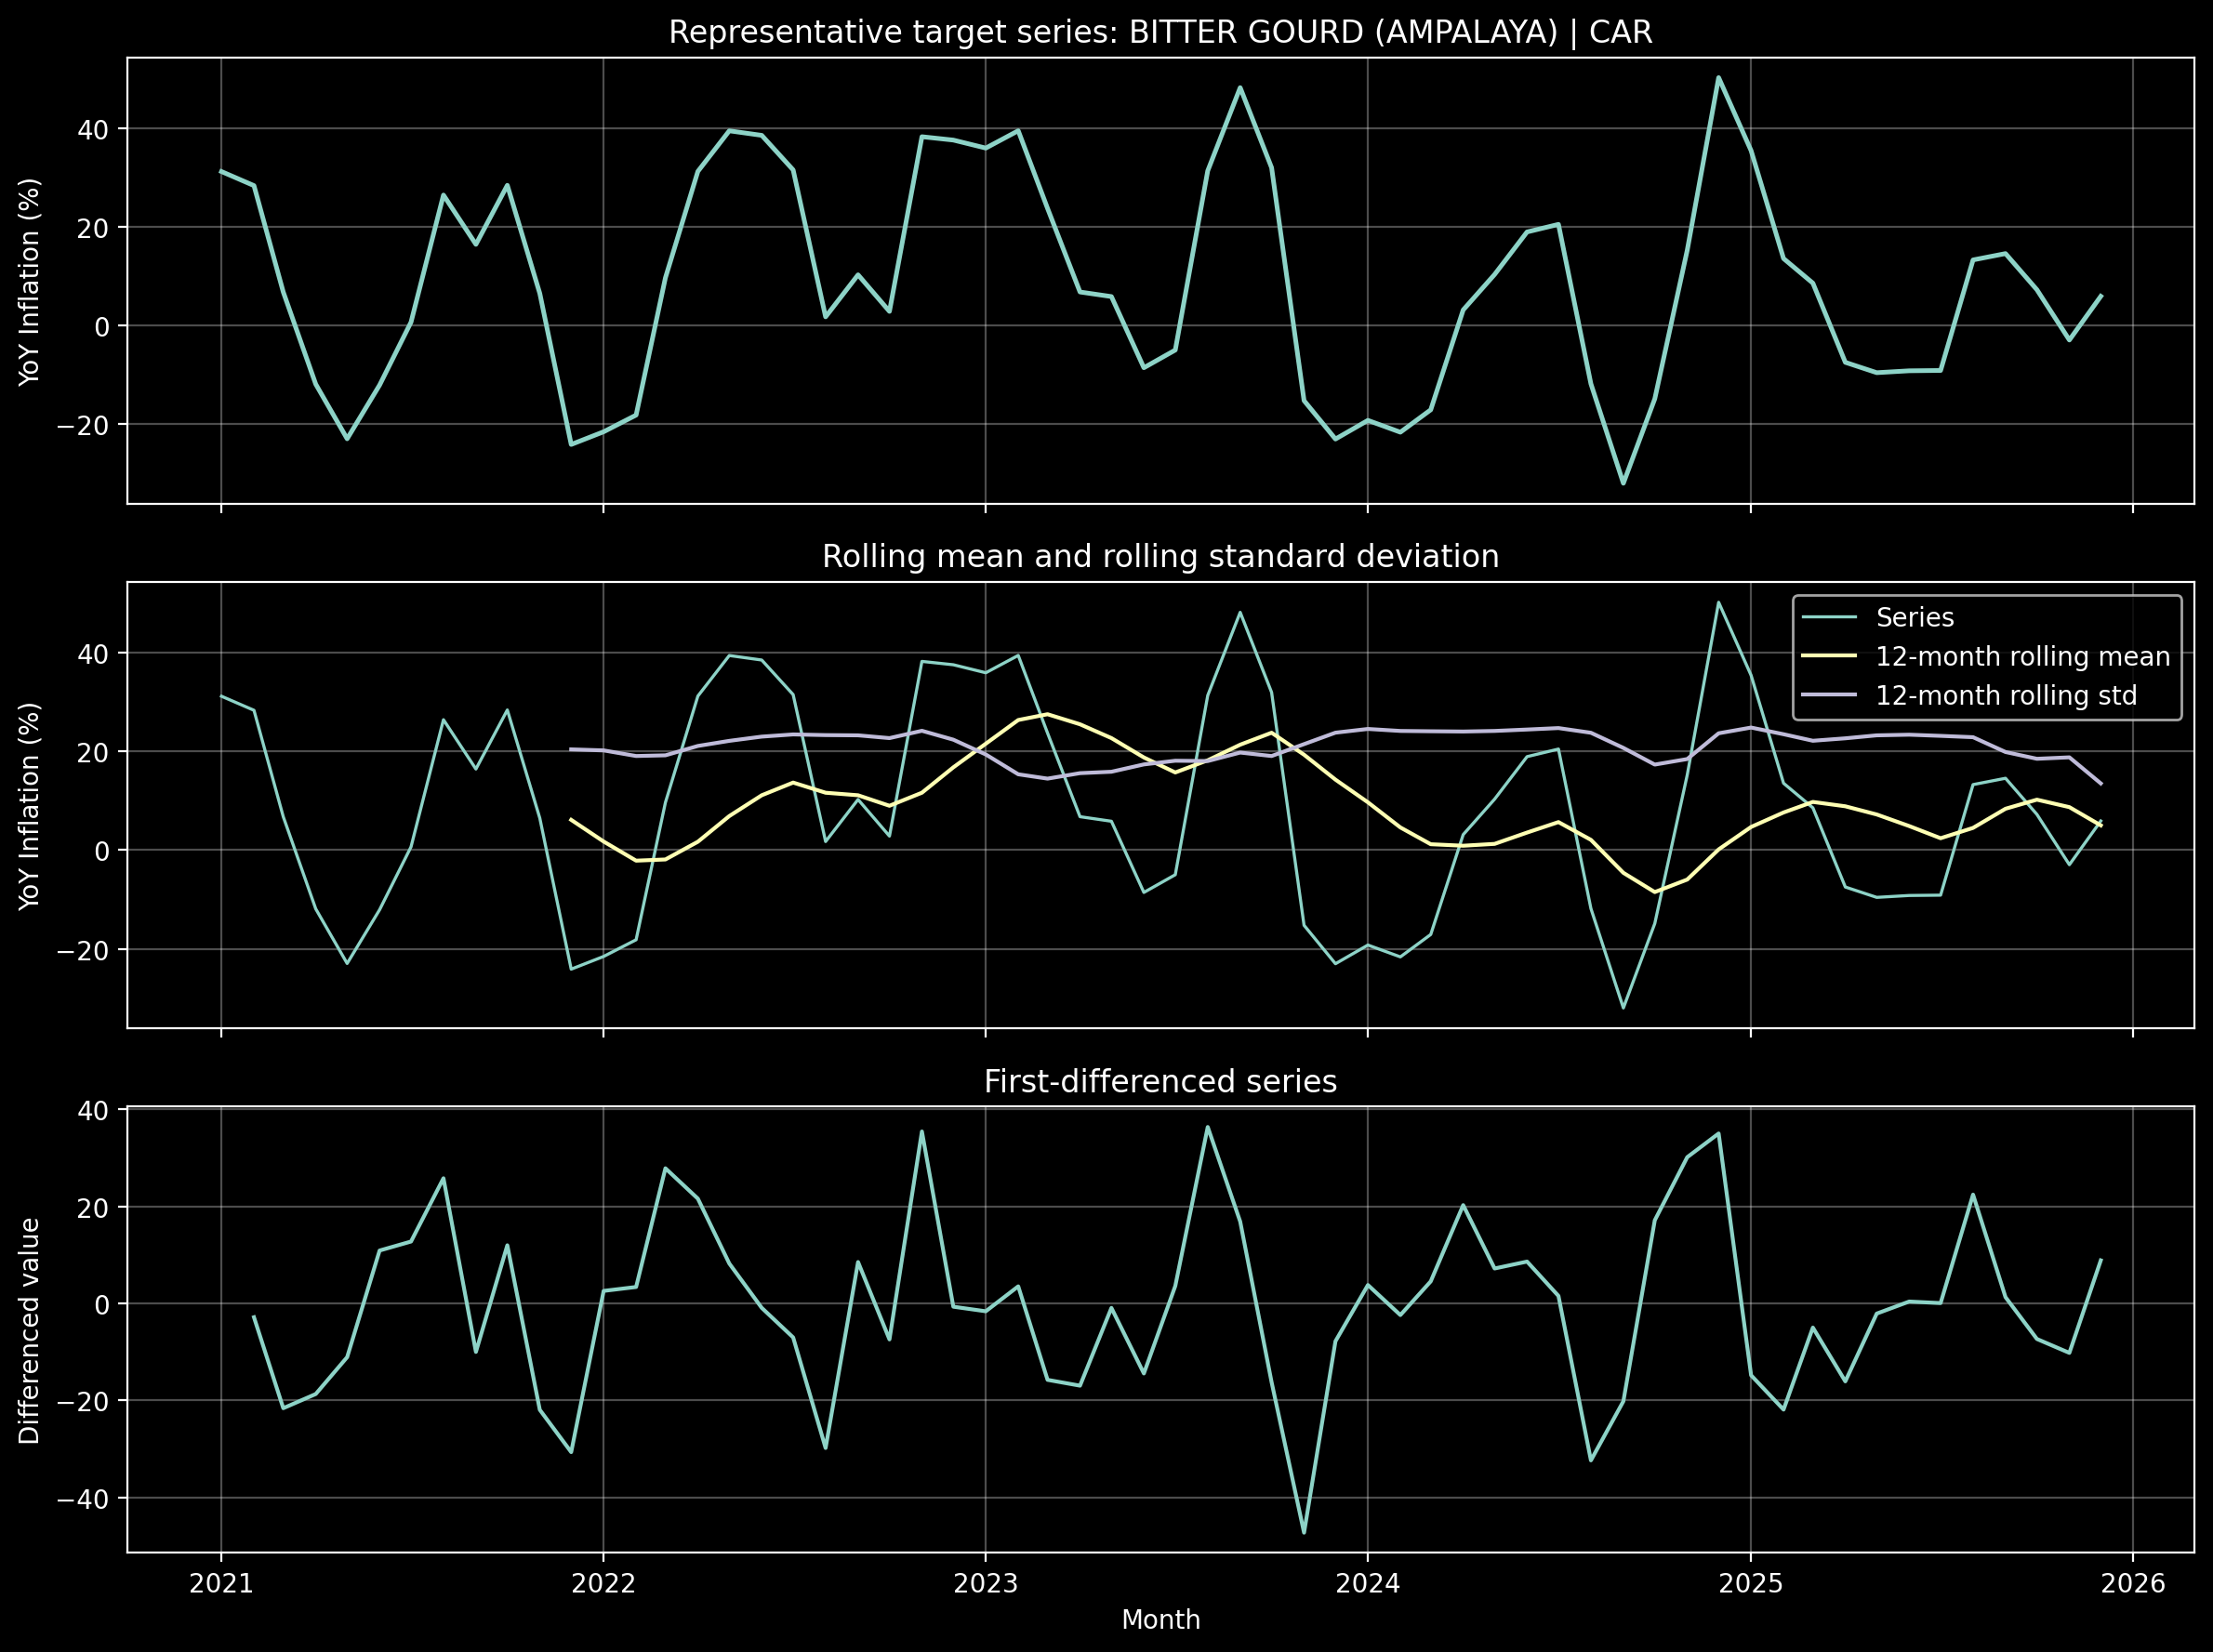

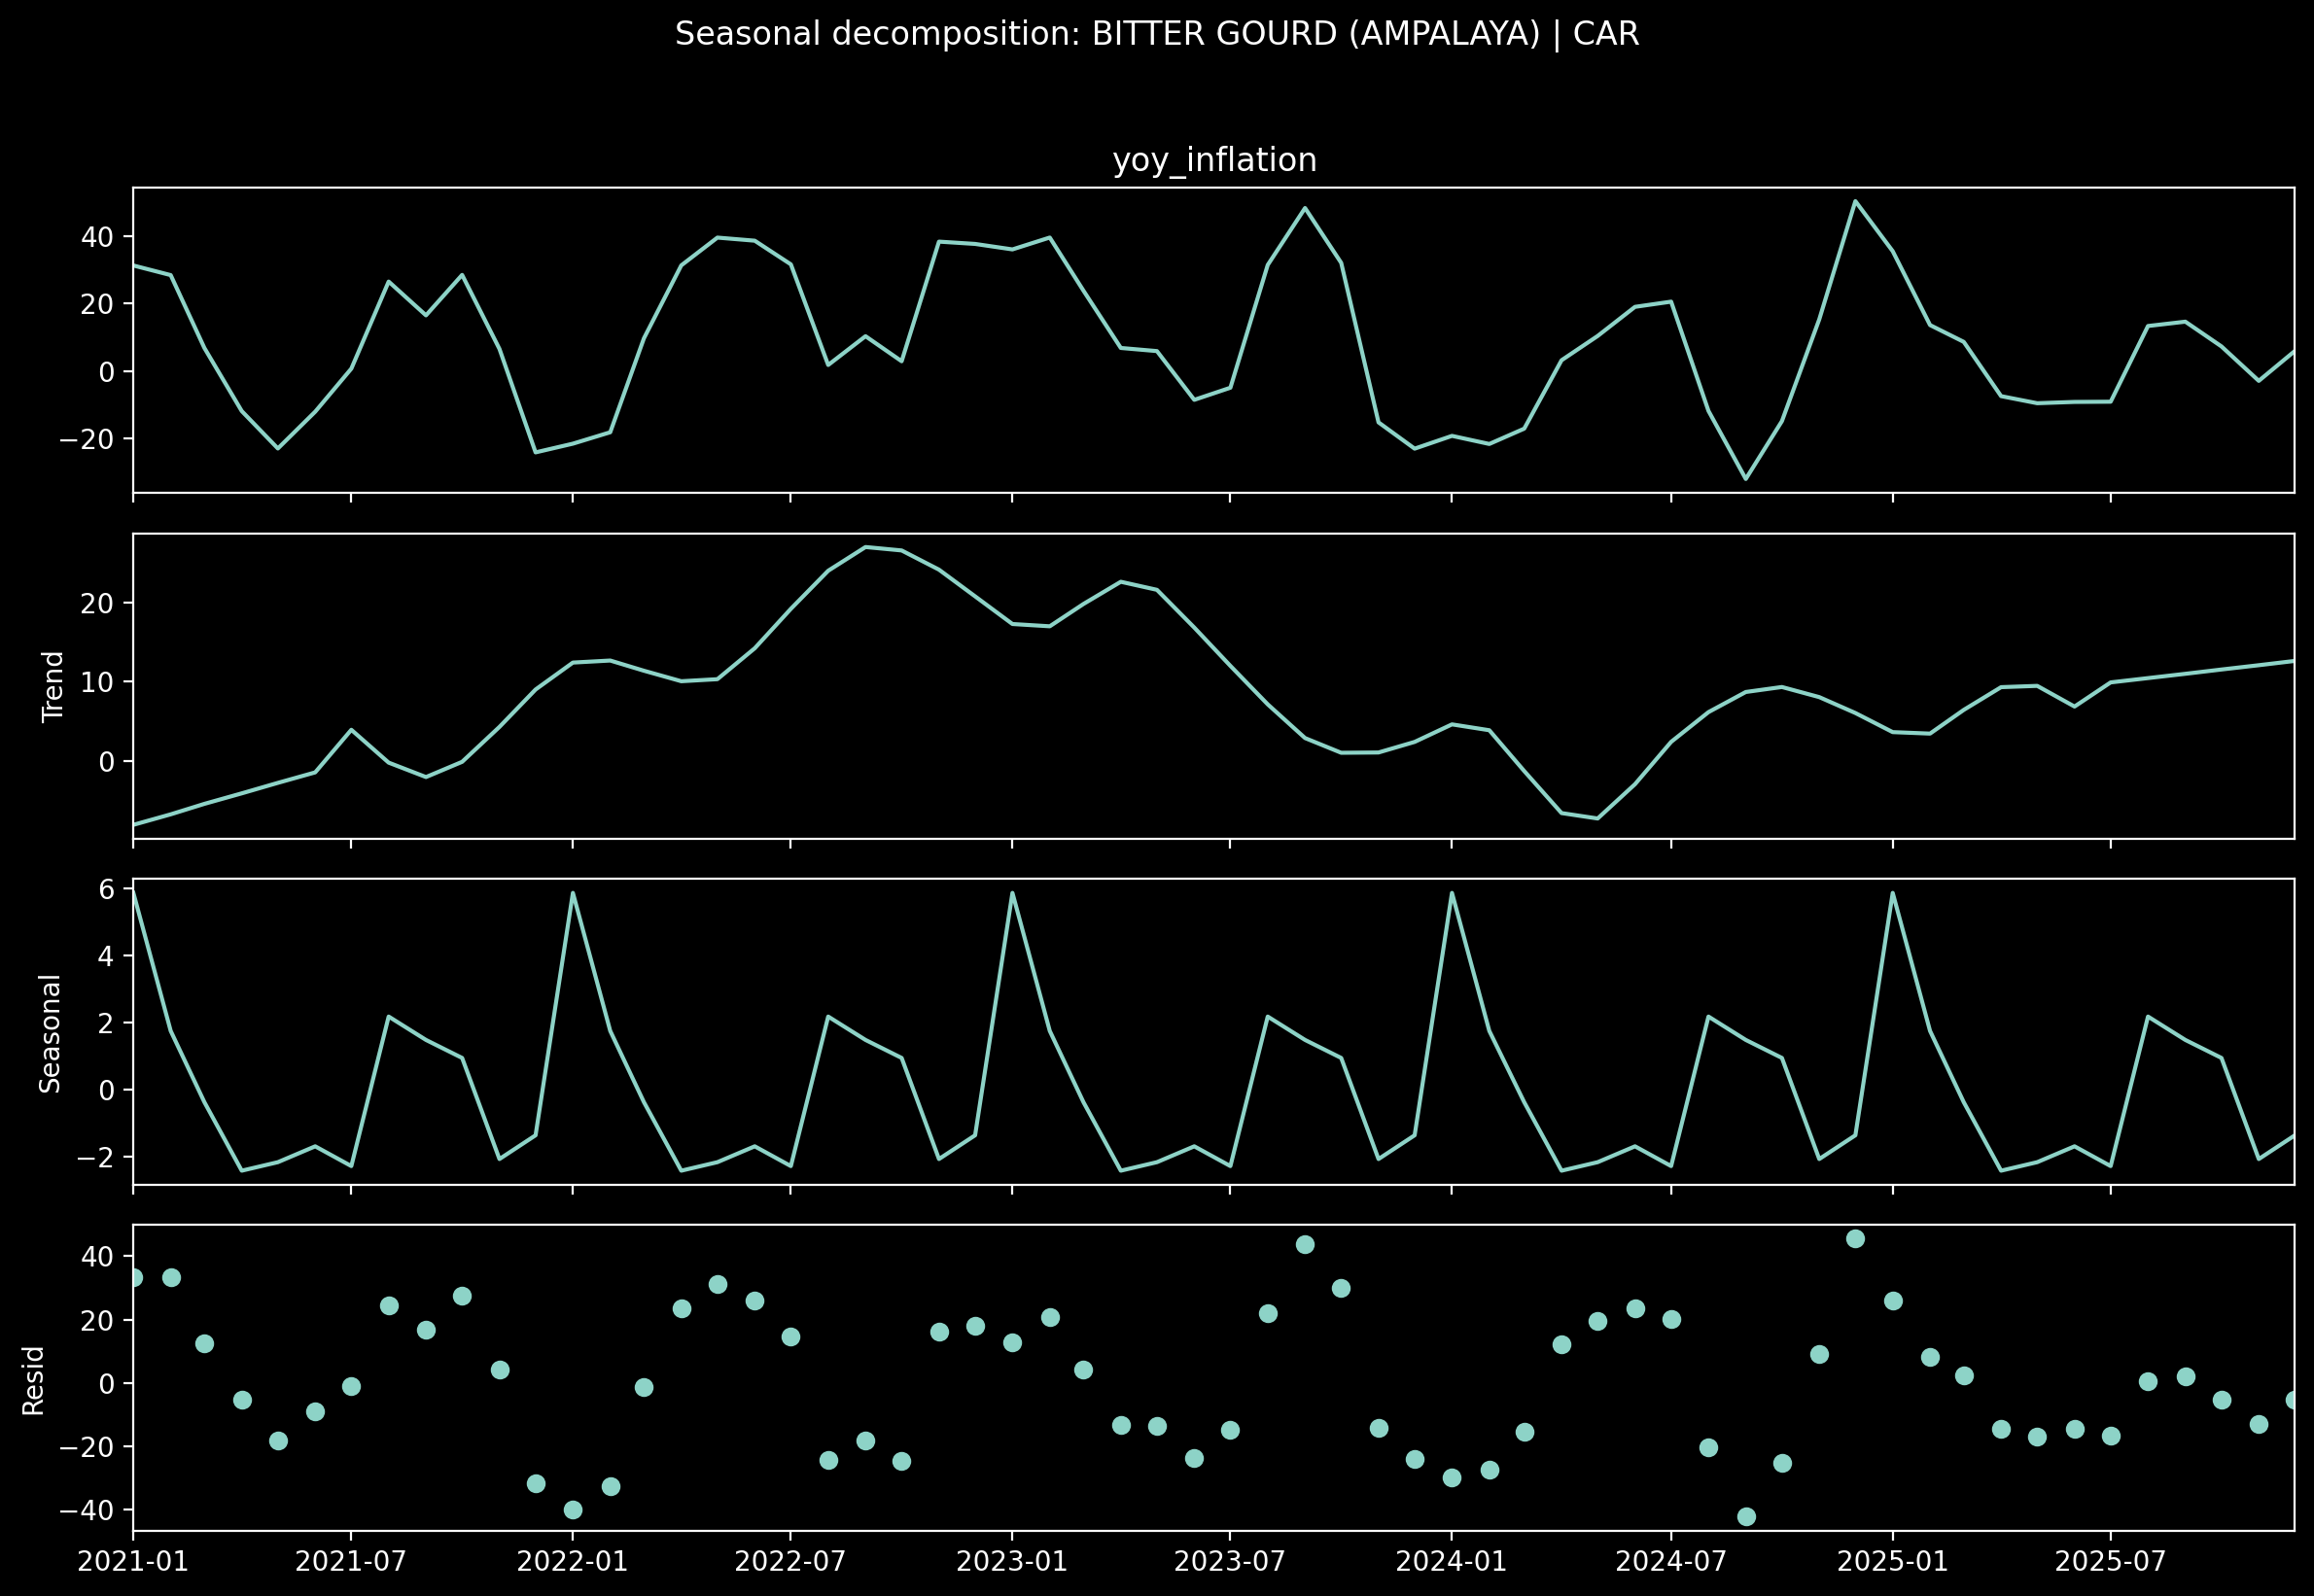

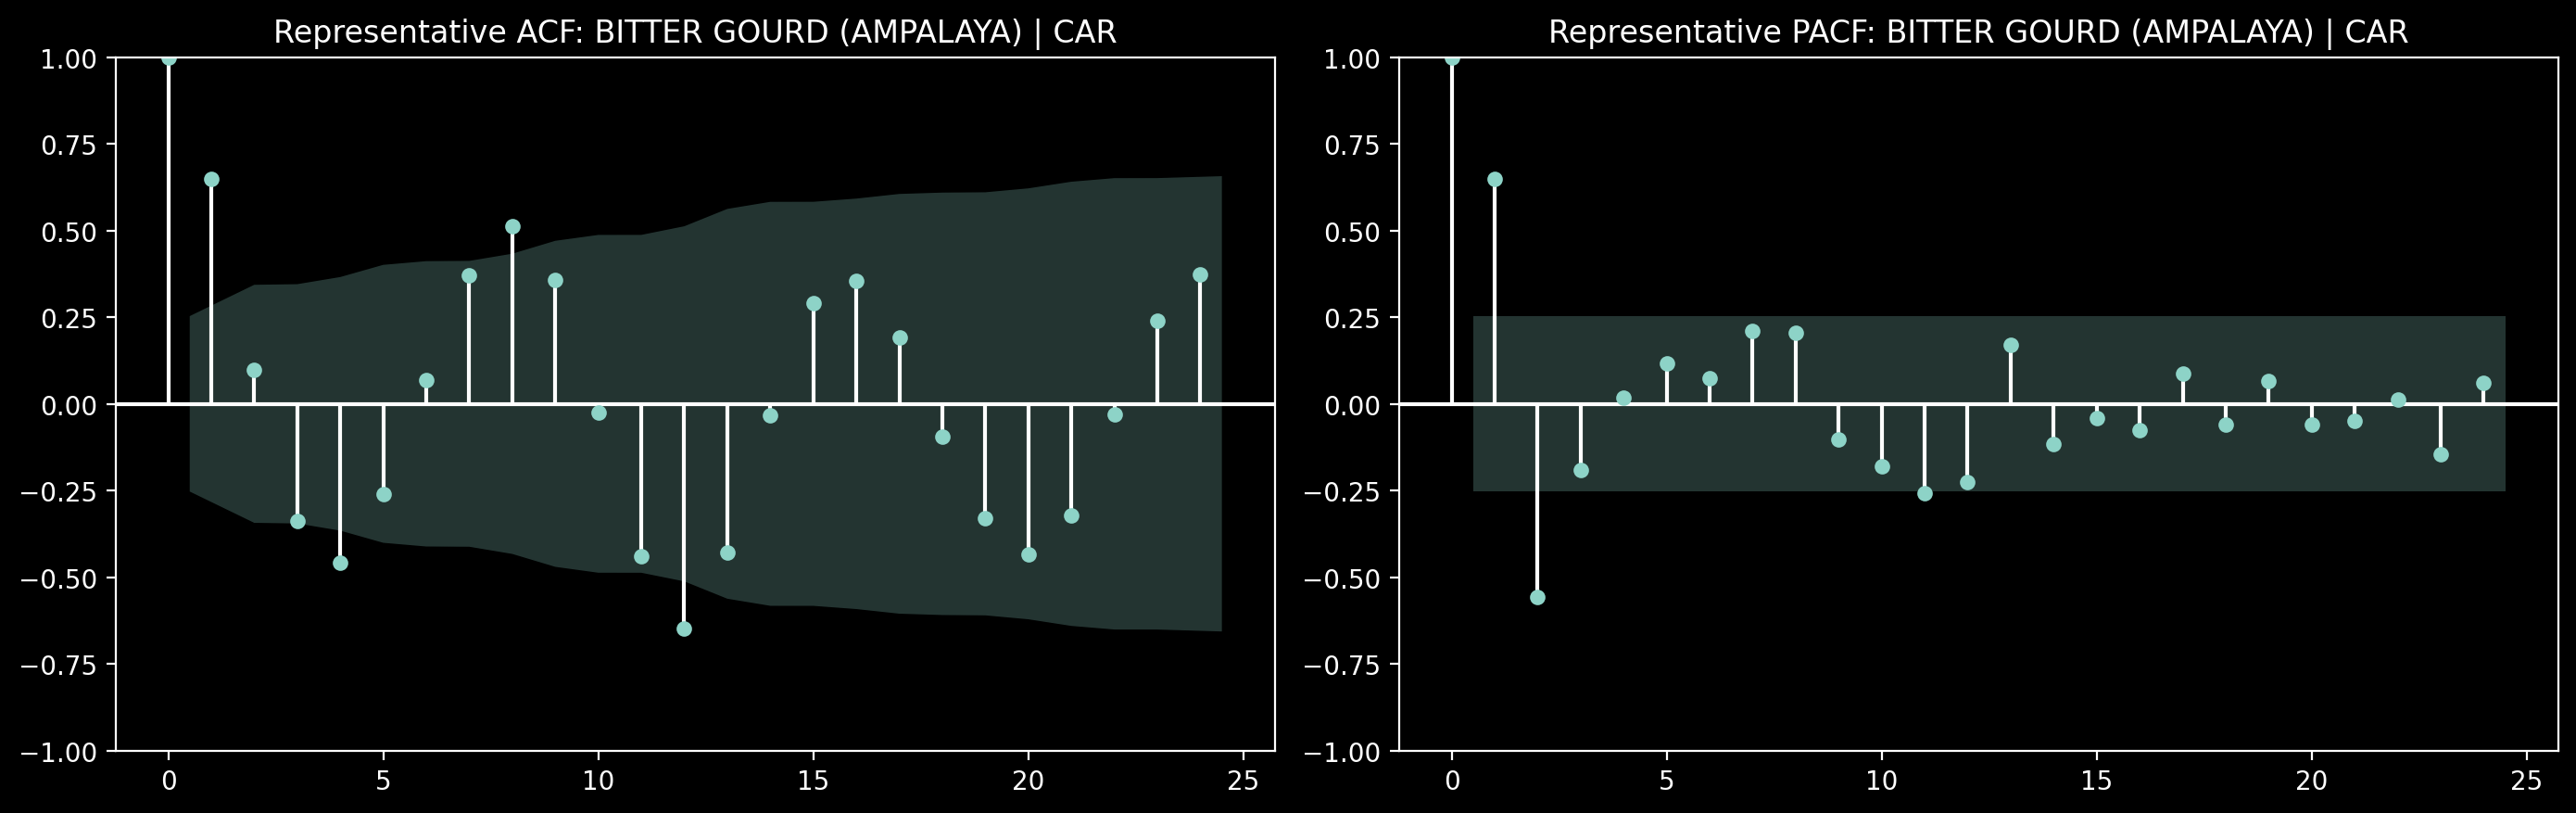

In [6]:
# Stationarity diagnostics
stationarity_rows = []

for series_id, part in eligible_panel.groupby("series_id"):
    target_series = part[TARGET_COL].dropna()

    adf_p_value_aic = hf.safe_adf_pvalue(target_series, autolag="AIC")
    adf_p_value_bic = hf.safe_adf_pvalue(target_series, autolag="BIC")

    recommended_d_aic = 0 if pd.notna(adf_p_value_aic) and adf_p_value_aic < 0.05 else 1 if pd.notna(adf_p_value_aic) else np.nan
    recommended_d_bic = 0 if pd.notna(adf_p_value_bic) and adf_p_value_bic < 0.05 else 1 if pd.notna(adf_p_value_bic) else np.nan

    if pd.notna(recommended_d_aic) and pd.notna(recommended_d_bic):
        recommended_d = int(max(recommended_d_aic, recommended_d_bic))
    elif pd.notna(recommended_d_aic):
        recommended_d = int(recommended_d_aic)
    elif pd.notna(recommended_d_bic):
        recommended_d = int(recommended_d_bic)
    else:
        recommended_d = np.nan

    stationarity_rows.append({
        "series_id": series_id,
        "region": part["region"].iloc[0],
        "commodity_name": part["commodity_name"].iloc[0],
        "target_rows": int(target_series.shape[0]),
        "adf_p_value_aic": adf_p_value_aic,
        "adf_p_value_bic": adf_p_value_bic,
        "recommended_d": recommended_d,
    })

stationarity_results = pd.DataFrame(stationarity_rows)

stationarity_overview = pd.DataFrame([
    {
        "series_tested": int(stationarity_results["series_id"].nunique()),
        "stationary_at_5pct_aic": int((stationarity_results["adf_p_value_aic"] < 0.05).sum()),
        "stationary_at_5pct_bic": int((stationarity_results["adf_p_value_bic"] < 0.05).sum()),
        "recommend_d_0": int((stationarity_results["recommended_d"] == 0).sum()),
        "recommend_d_1": int((stationarity_results["recommended_d"] == 1).sum()),
    }
])


# Seasonality diagnostics
seasonality_rows = []

for series_id, part in eligible_panel.groupby("series_id"):
    target_series = part[TARGET_COL]
    lag12_autocorr = hf.lagged_autocorr(target_series, SEASONAL_PERIOD)
    month_profile = part.groupby("month_num")[TARGET_COL].mean().reindex(range(1, 13))
    month_profile_std = month_profile.std() if not month_profile.empty else np.nan
    recommended_D = 1 if pd.notna(lag12_autocorr) and abs(lag12_autocorr) >= 0.20 else 0 if pd.notna(lag12_autocorr) else np.nan

    seasonality_rows.append({
        "series_id": series_id,
        "region": part["region"].iloc[0],
        "commodity_name": part["commodity_name"].iloc[0],
        "lag12_autocorr": lag12_autocorr,
        "month_profile_std": month_profile_std,
        "recommended_D": recommended_D,
    })

seasonality_results = pd.DataFrame(seasonality_rows)

seasonality_overview = pd.DataFrame([
    {
        "series_checked": int(seasonality_results["series_id"].nunique()),
        "strong_lag12_signal": int((seasonality_results["lag12_autocorr"].abs() >= 0.20).sum()),
        "recommend_D_0": int((seasonality_results["recommended_D"] == 0).sum()),
        "recommend_D_1": int((seasonality_results["recommended_D"] == 1).sum()),
    }
])


# Top seasonal candidates
top_seasonal_candidates = (
    seasonality_results.sort_values(
        ["recommended_D", "lag12_autocorr", "month_profile_std"],
        ascending=[False, False, False]
    )
    .head(15)
    .reset_index(drop=True)
)


# SARIMA readiness table
sarima_readiness = (
    eligible_series_manifest[
        ["series_id", "region", "commodity_name", "months_total", "price_rows", "mom_rows", "yoy_rows"]
    ]
    .merge(
        split_readiness[["series_id", "target_rows", "walk_forward_ready"]],
        on="series_id",
        how="left"
    )
    .merge(
        stationarity_results[["series_id", "adf_p_value_aic", "adf_p_value_bic", "recommended_d"]],
        on="series_id",
        how="left"
    )
    .merge(
        seasonality_results[["series_id", "lag12_autocorr", "recommended_D", "month_profile_std"]],
        on="series_id",
        how="left"
    )
)

sarima_readiness_overview = pd.DataFrame([
    {
        "selected_target": TARGET_COL,
        "eligible_series": int(sarima_readiness["series_id"].nunique()),
        "walk_forward_ready_series": int(sarima_readiness["walk_forward_ready"].fillna(False).sum()),
        "median_target_rows": float(sarima_readiness["target_rows"].median()),
        "median_series_length": float(sarima_readiness["months_total"].median()),
    }
])


# Visual 1: Series-length distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(regional_series_manifest["months_total"].dropna(), bins=20)
ax.set_title("Distribution of usable series length")
ax.set_xlabel("Months per series")
ax.set_ylabel("Number of series")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig("visuals/1.4.a Series Length Distribution.png", dpi=200, bbox_inches="tight")
plt.close()

# Visual 2: Seasonality-strength distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(seasonality_results["lag12_autocorr"].dropna(), bins=20)
ax.set_title("Distribution of lag-12 autocorrelation across series")
ax.set_xlabel("Lag-12 autocorrelation")
ax.set_ylabel("Number of series")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig("visuals/1.4.b Lag12 Autocorrelation Distribution.png", dpi=200, bbox_inches="tight")
plt.close()

# Visual 3: Seasonal heatmap across strongest seasonal candidates
top_ids = top_seasonal_candidates["series_id"].head(10).tolist()

heatmap_panel = eligible_panel.loc[
    eligible_panel["series_id"].isin(top_ids)
].copy()

heatmap_data = (
    heatmap_panel.groupby(["series_id", "month_num"])[TARGET_COL]
    .mean()
    .unstack("month_num")
)

if not heatmap_data.empty:
    heatmap_labels = (
        heatmap_panel.groupby("series_id")[["region", "commodity_name"]]
        .first()
        .apply(lambda row: f"{row['commodity_name']} | {row['region']}", axis=1)
    )
    heatmap_data = heatmap_data.loc[heatmap_labels.index]

    fig, ax = plt.subplots(figsize=(12, max(4, len(heatmap_data) * 0.5)))
    im = ax.imshow(heatmap_data.values, aspect="auto")

    ax.set_title("Monthly seasonal profile across top candidate series")
    ax.set_xlabel("Calendar month")
    ax.set_ylabel("Commodity | Region")
    ax.set_xticks(range(12))
    ax.set_xticklabels(range(1, 13))
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_labels.values)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(TARGET_LABEL)

    fig.tight_layout()
    plt.savefig("visuals/1.4.c Seasonal Heatmap Top Candidates.png", dpi=200, bbox_inches="tight")
    plt.close()

# Representative-series diagnostics
representative_series_id = None

representative_candidates = (
    seasonality_results
    .merge(
        split_readiness[["series_id", "walk_forward_ready"]],
        on="series_id",
        how="left"
    )
    .merge(
        stationarity_results[["series_id", "recommended_d"]],
        on="series_id",
        how="left"
    )
)

representative_candidates = representative_candidates.loc[
    representative_candidates["walk_forward_ready"].fillna(False)
].copy()

representative_candidates["abs_lag12"] = representative_candidates["lag12_autocorr"].abs()
representative_candidates = representative_candidates.sort_values(
    ["recommended_D", "abs_lag12", "month_profile_std"],
    ascending=[False, False, False]
)

if not representative_candidates.empty:
    representative_series_id = representative_candidates.iloc[0]["series_id"]

# Visual 4: Representative stationarity diagnostics
# Visual 5: Representative seasonal decomposition
# Visual 6: Representative ACF/PACF
if representative_series_id is not None:
    representative_part = eligible_panel.loc[
        eligible_panel["series_id"] == representative_series_id
    ].dropna(subset=[TARGET_COL]).sort_values("month").copy()

    representative_meta = (
        representative_part[["region", "commodity_name"]]
        .head(1)
        .iloc[0]
    )
    representative_label = f"{representative_meta['commodity_name']} | {representative_meta['region']}"

    representative_target = representative_part.set_index("month")[TARGET_COL].asfreq("MS")
    representative_target = representative_target.interpolate(limit_direction="both")

    rolling_mean = representative_target.rolling(window=12).mean()
    rolling_std = representative_target.rolling(window=12).std()
    diff_target = representative_target.diff()

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(representative_target.index, representative_target.values, linewidth=1.8)
    axes[0].set_title(f"Representative target series: {representative_label}")
    axes[0].set_ylabel(TARGET_LABEL)
    axes[0].grid(alpha=0.3)

    axes[1].plot(representative_target.index, representative_target.values, linewidth=1.2, label="Series")
    axes[1].plot(rolling_mean.index, rolling_mean.values, linewidth=1.5, label="12-month rolling mean")
    axes[1].plot(rolling_std.index, rolling_std.values, linewidth=1.5, label="12-month rolling std")
    axes[1].set_title("Rolling mean and rolling standard deviation")
    axes[1].set_ylabel(TARGET_LABEL)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(diff_target.index, diff_target.values, linewidth=1.5)
    axes[2].set_title("First-differenced series")
    axes[2].set_ylabel("Differenced value")
    axes[2].set_xlabel("Month")
    axes[2].grid(alpha=0.3)

    fig.tight_layout()
    plt.savefig("visuals/1.4.d Representative Stationarity Diagnostics.png", dpi=200, bbox_inches="tight")
    plt.close()

    if representative_target.shape[0] >= 24:
        decomposition = seasonal_decompose(
            representative_target,
            model="additive",
            period=SEASONAL_PERIOD,
            extrapolate_trend="freq",
        )
        decomposition_fig = decomposition.plot()
        decomposition_fig.set_size_inches(12, 8)
        decomposition_fig.suptitle(f"Seasonal decomposition: {representative_label}", y=1.02)
        decomposition_fig.tight_layout()
        decomposition_fig.savefig("visuals/1.4.e Representative Seasonal Decomposition.png", dpi=200, bbox_inches="tight")
        plt.close(decomposition_fig)

    max_lag = min(24, int(representative_target.shape[0] // 2) - 1)

    if max_lag >= 12:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        plot_acf(representative_target, lags=max_lag, ax=axes[0])
        axes[0].set_title(f"Representative ACF: {representative_label}")
        plot_pacf(representative_target, lags=max_lag, ax=axes[1], method="ywm")
        axes[1].set_title(f"Representative PACF: {representative_label}")
        fig.tight_layout()
        plt.savefig("visuals/1.4.f Representative ACF PACF.png", dpi=200, bbox_inches="tight")
        plt.close()

display(stationarity_overview)
display(seasonality_overview)
display(top_seasonal_candidates)
display(sarima_readiness_overview)
display_saved_images(
    "visuals/1.4.a Series Length Distribution.png",
    "visuals/1.4.b Lag12 Autocorrelation Distribution.png",
    "visuals/1.4.c Seasonal Heatmap Top Candidates.png",
    "visuals/1.4.d Representative Stationarity Diagnostics.png",
    "visuals/1.4.e Representative Seasonal Decomposition.png",
    "visuals/1.4.f Representative ACF PACF.png",
)


# SARIMA Benchmarking


## Search Space


In [7]:
# 2.  SARIMA Benchmarking and Evaluation
sarima_ready_manifest = sarima_readiness.loc[
    sarima_readiness["walk_forward_ready"].fillna(False)
].copy()

sarima_search_space = pd.DataFrame([
    {
        "target_column": TARGET_COL,
        "holdout_ratio": HOLDOUT_RATIO,
        "minimum_train_observations": MIN_TRAIN_OBS_SARIMA,
        "inner_folds": INNER_FOLDS_SARIMA,
        "seasonal_period": SEASONAL_PERIOD,
        "p_values": str(SARIMA_P_VALUES),
        "q_values": str(SARIMA_Q_VALUES),
        "P_values": str(SARIMA_P_SEASONAL_VALUES),
        "Q_values": str(SARIMA_Q_SEASONAL_VALUES),
        "trend_values": str(SARIMA_TREND_VALUES),
        "series_selected": int(len(sarima_ready_manifest)),
    }
])

display(sarima_search_space)
hf.log_progress(
    f"2.1 SARIMA search space ready: {len(sarima_ready_manifest):,} series, {SARIMA_N_JOBS} workers, "
    f"parallel={RUNTIME_CONFIG['use_parallel_sarima']}"
)


,target_column,holdout_ratio,minimum_train_observations,inner_folds,seasonal_period,p_values,q_values,P_values,Q_values,trend_values,series_selected
0,yoy_inflation,0.2,24,5,12,"[0, 1, 2]","[0, 1, 2]","[0, 1]","[0, 1]","['n', 'c']",100


## Results


In [ ]:
series_lookup = {
    series_id: part.copy()
    for series_id, part in eligible_panel.groupby("series_id")
}

def run_one_sarima(meta_row, series_lookup):
    meta_dict = meta_row.to_dict()
    series_frame = series_lookup[meta_dict["series_id"]]
    return hf.run_sarima_for_series(meta_dict, series_frame)

if RUNTIME_CONFIG["use_parallel_sarima"] and not sarima_ready_manifest.empty:
    with hf.joblib_progress("SARIMA series", total=len(sarima_ready_manifest)):
        sarima_outputs = Parallel(
            n_jobs=SARIMA_N_JOBS,
            backend="loky",
            batch_size=1,
            verbose=0,
        )(
            delayed(run_one_sarima)(meta_row, series_lookup)
            for _, meta_row in sarima_ready_manifest.iterrows()
        )
else:
    sarima_outputs = []
    hf.log_progress(f"SARIMA series: started 0/{len(sarima_ready_manifest)}")
    for completed, (_, meta_row) in enumerate(sarima_ready_manifest.iterrows(), start=1):
        sarima_outputs.append(run_one_sarima(meta_row, series_lookup))
        hf.log_completed_task("SARIMA series", completed, len(sarima_ready_manifest), hf.series_label(meta_row))


sarima_results_rows = []
sarima_settings_rows = []

for result in sarima_outputs:
    if result.get("settings") is not None:
        sarima_settings_rows.append(result["settings"])
    sarima_results_rows.extend(result.get("predictions", []))

sarima_predictions = pd.DataFrame(sarima_results_rows)
sarima_model_settings = pd.DataFrame(sarima_settings_rows)

sarima_run_overview = pd.DataFrame([
    {
        "series_modeled": int(sarima_model_settings["series_id"].nunique()) if not sarima_model_settings.empty else 0,
        "holdout_predictions": int(len(sarima_predictions)),
        "average_holdout_rows_per_series": float(sarima_model_settings["holdout_rows"].mean()) if not sarima_model_settings.empty else np.nan,
    }
])


prediction_pairs = [
    ("Naive", "naive_pred"),
    ("Seasonal Naive", "seasonal_naive_pred"),
    ("SARIMA", "sarima_pred"),
]

sarima_global_metrics = hf.compute_metrics_table(sarima_predictions, prediction_pairs)
sarima_series_metrics = hf.compute_series_metrics(sarima_predictions, prediction_pairs)

sarima_residual_diagnostics = hf.compute_diagnostics(sarima_predictions, prediction_pairs)
hf.save_residual_distribution_plots(
    sarima_predictions,
    prediction_pairs,
    "visuals/2.2.d Residual Histograms.png",
    "visuals/2.2.e Residual QQ Plots.png",
    "SARIMA Evaluation",
)

# Visual 1: Benchmark comparison
if not sarima_global_metrics.empty:
    benchmark_plot = sarima_global_metrics.set_index("model").loc[["Naive", "Seasonal Naive", "SARIMA"]].reset_index()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(benchmark_plot["model"], benchmark_plot["rmse"])
    ax.set_title("Forecast benchmark comparison by RMSE")
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.savefig("visuals/2.2.a Benchmark RMSE Comparison.png", dpi=200, bbox_inches="tight")
    plt.close()

# Visual 2: Frequent SARIMA orders
if not sarima_model_settings.empty:
    sarima_order_frequency = (
        sarima_model_settings.assign(
            order_label=sarima_model_settings["sarima_order"] + " x " + sarima_model_settings["sarima_seasonal_order"]
        )["order_label"]
        .value_counts()
        .head(15)
        .rename_axis("order_label")
        .reset_index(name="series_count")
    )


    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sarima_order_frequency["order_label"], sarima_order_frequency["series_count"])
    ax.set_title("Most frequent SARIMA orders")
    ax.set_xlabel("Number of series")
    ax.set_ylabel("SARIMA order")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    plt.savefig("visuals/2.2.b SARIMA Order Frequency.png", dpi=200, bbox_inches="tight")
    plt.close()

# Visual 3: Best-example holdout forecasts
if not sarima_series_metrics.empty:
    example_series = (
        sarima_series_metrics.loc[sarima_series_metrics["model"] == "SARIMA"]
        .sort_values("rmse")
        .head(4)
    )

    if not example_series.empty:
        fig, axes = plt.subplots(len(example_series), 1, figsize=(12, 3.5 * len(example_series)), sharex=False)

        if len(example_series) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, example_series.iterrows()):
            part = sarima_predictions.loc[
                sarima_predictions["series_id"] == row["series_id"]
            ].sort_values("month")

            ax.plot(part["month"], part["actual"], marker="o", linewidth=2, label="Actual")
            ax.plot(part["month"], part["sarima_pred"], marker="o", linewidth=1.8, label="SARIMA")
            ax.plot(part["month"], part["seasonal_naive_pred"], linestyle="--", linewidth=1.3, label="Seasonal Naive")
            ax.plot(part["month"], part["naive_pred"], linestyle=":", linewidth=1.3, label="Naive")
            ax.set_title(f"{row['commodity_name']} | {row['region']}")
            ax.set_ylabel(TARGET_LABEL)
            ax.grid(alpha=0.3)
            ax.legend(loc="best")

        axes[-1].set_xlabel("Holdout month")
        fig.tight_layout()
        plt.savefig("visuals/2.2.c Best Example Holdout Forecasts.png", dpi=200, bbox_inches="tight")
        plt.close()

display(sarima_run_overview)
display(sarima_global_metrics)
display(sarima_series_metrics.head(10))
display(sarima_residual_diagnostics.head(10))
if "sarima_order_frequency" in locals():
    display(sarima_order_frequency)
display_saved_images(
    "visuals/2.2.a Benchmark RMSE Comparison.png",
    "visuals/2.2.b SARIMA Order Frequency.png",
    "visuals/2.2.c Best Example Holdout Forecasts.png",
)


# SVR Benchmarking


## Results


In [ ]:
# 3. SVR Benchmarking and Evaluation

SVR_BASE_FEATURES = [feature for feature in SVR_BASE_FEATURES if feature in eligible_panel.columns]

MIN_TRAIN_OBS_ML = MIN_TRAIN_OBS_SARIMA
INNER_FOLDS_ML = INNER_FOLDS_SARIMA

non_linear_ready_manifest = sarima_readiness.loc[
    sarima_readiness["walk_forward_ready"].fillna(False)
].copy()

svr_feature_manifest = pd.DataFrame([
    {
        "candidate_series": int(len(non_linear_ready_manifest)),
        "svr_feature_count": int(len(SVR_BASE_FEATURES)),
        "svr_features": ", ".join(SVR_BASE_FEATURES),
    }
])

svr_predictions, svr_model_settings = hf.run_svr_models(
    non_linear_ready_manifest,
    eligible_panel,
    SVR_BASE_FEATURES,
    cv_n_jobs=SKLEARN_N_JOBS,
)

non_linear_predictions = sarima_predictions.merge(
    svr_predictions[
        [
            "series_id",
            "region",
            "commodity_name",
            "month",
            "svr_pred",
        ]
    ],
    on=["series_id", "region", "commodity_name", "month"],
    how="inner",
)

svr_prediction_pairs = [
    ("Naive", "naive_pred"),
    ("Seasonal Naive", "seasonal_naive_pred"),
    ("SARIMA", "sarima_pred"),
    ("SVR", "svr_pred"),
]

svr_run_overview = pd.DataFrame([
    {
        "prediction_rows": int(len(non_linear_predictions)),
        "svr_models": int(len(svr_model_settings)),
        "svr_feature_count": int(len(SVR_BASE_FEATURES)),
    }
])

svr_global_metrics = hf.compute_metrics_table(non_linear_predictions, svr_prediction_pairs)
svr_series_metrics = hf.compute_series_metrics(non_linear_predictions, svr_prediction_pairs)
svr_residual_diagnostics = hf.compute_diagnostics(non_linear_predictions, svr_prediction_pairs)

hf.save_residual_distribution_plots(
    non_linear_predictions,
    svr_prediction_pairs,
    "visuals/3.2.c Residual Histograms.png",
    "visuals/3.2.d Residual QQ Plots.png",
    "SVR Evaluation",
)

# Visual 1: Benchmark comparison
if not svr_global_metrics.empty:
    benchmark_plot = svr_global_metrics.set_index("model").loc[
        ["Naive", "Seasonal Naive", "SARIMA", "SVR"]
    ].reset_index()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(benchmark_plot["model"], benchmark_plot["rmse"])
    ax.set_title("Forecast benchmark comparison by RMSE")
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.savefig("visuals/3.2.a SVR Benchmark RMSE Comparison.png", dpi=200, bbox_inches="tight")
    plt.close()

# Visual 2: Best SVR examples
if not svr_series_metrics.empty:
    example_series = (
        svr_series_metrics.loc[svr_series_metrics["model"] == "SVR"]
        .sort_values("rmse")
        .head(4)
    )

    if not example_series.empty:
        fig, axes = plt.subplots(len(example_series), 1, figsize=(12, 3.5 * len(example_series)), sharex=False)

        if len(example_series) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, example_series.iterrows()):
            part = non_linear_predictions.loc[
                non_linear_predictions["series_id"] == row["series_id"]
            ].sort_values("month")

            ax.plot(part["month"], part["actual"], marker="o", linewidth=2, label="Actual")
            ax.plot(part["month"], part["svr_pred"], marker="o", linewidth=1.8, label="SVR")
            ax.plot(part["month"], part["sarima_pred"], linestyle="-.", linewidth=1.3, label="SARIMA")
            ax.plot(part["month"], part["seasonal_naive_pred"], linestyle="--", linewidth=1.3, label="Seasonal Naive")
            ax.plot(part["month"], part["naive_pred"], linestyle=":", linewidth=1.3, label="Naive")
            ax.set_title(f"{row['commodity_name']} | {row['region']}")
            ax.set_ylabel(TARGET_LABEL)
            ax.grid(alpha=0.3)
            ax.legend(loc="best")

        axes[-1].set_xlabel("Holdout month")
        fig.tight_layout()
        plt.savefig("visuals/3.2.b Best Example SVR Forecasts.png", dpi=200, bbox_inches="tight")
        plt.close()

display(svr_feature_manifest)
display(svr_run_overview)
display(svr_global_metrics)
display(svr_series_metrics.head(10))
display(svr_residual_diagnostics.head(10))
display_saved_images(
    "visuals/3.2.a SVR Benchmark RMSE Comparison.png",
    "visuals/3.2.b Best Example SVR Forecasts.png",
)


# LightGBM Benchmarking


## Results and Table 2


In [ ]:
# 3. LightGBM
LIGHTGBM_BASE_FEATURES = [feature for feature in LIGHTGBM_BASE_FEATURES if feature in eligible_panel.columns]

lightgbm_exog_candidates = [feature for feature in global_exogenous_feature_columns if feature in eligible_panel.columns]
if lightgbm_exog_candidates:
    lightgbm_exog_coverage = eligible_panel[lightgbm_exog_candidates].notna().mean().sort_values(ascending=False)
    LIGHTGBM_EXOG_FEATURES = lightgbm_exog_coverage.loc[lightgbm_exog_coverage >= 0.60].index.tolist()[:8]
else:
    lightgbm_exog_coverage = pd.Series(dtype=float)
    LIGHTGBM_EXOG_FEATURES = []

LIGHTGBM_FEATURES = LIGHTGBM_BASE_FEATURES + LIGHTGBM_EXOG_FEATURES

lightgbm_feature_manifest = pd.DataFrame([
    {
        "candidate_series": int(len(non_linear_ready_manifest)),
        "lightgbm_base_feature_count": int(len(LIGHTGBM_BASE_FEATURES)),
        "lightgbm_exogenous_feature_count": int(len(LIGHTGBM_EXOG_FEATURES)),
        "lightgbm_total_feature_count": int(len(LIGHTGBM_FEATURES)),
        "lightgbm_features": ", ".join(LIGHTGBM_FEATURES),
    }
])

lightgbm_predictions, lightgbm_model_settings = hf.run_lightgbm_models(
    non_linear_ready_manifest,
    eligible_panel,
    LIGHTGBM_FEATURES,
    LIGHTGBM_EXOG_FEATURES,
    lightgbm_n_jobs=LIGHTGBM_N_JOBS,
)

if lightgbm_predictions.empty:
    non_linear_predictions["lightgbm_pred"] = non_linear_predictions["naive_pred"]
else:
    non_linear_predictions = non_linear_predictions.merge(
        lightgbm_predictions[
            ["series_id", "region", "commodity_name", "month", "lightgbm_pred"]
        ],
        on=["series_id", "region", "commodity_name", "month"],
        how="inner",
    )

lightgbm_run_overview = pd.DataFrame([
    {
        "prediction_rows": int(len(non_linear_predictions)),
        "lightgbm_models": int(len(lightgbm_model_settings)),
        "lightgbm_prediction_rows": int(len(lightgbm_predictions)),
        "lightgbm_exogenous_feature_count": int(len(LIGHTGBM_EXOG_FEATURES)),
    }
])

lightgbm_prediction_pairs = [
    ("Naive", "naive_pred"),
    ("Seasonal Naive", "seasonal_naive_pred"),
    ("SARIMA", "sarima_pred"),
    ("SVR", "svr_pred"),
    ("LightGBM", "lightgbm_pred"),
]

lightgbm_global_metrics = hf.compute_metrics_table(non_linear_predictions, lightgbm_prediction_pairs)
lightgbm_series_metrics = hf.compute_series_metrics(non_linear_predictions, lightgbm_prediction_pairs)
lightgbm_diagnostics = hf.compute_diagnostics(non_linear_predictions, lightgbm_prediction_pairs)

hf.save_residual_distribution_plots(
    non_linear_predictions,
    lightgbm_prediction_pairs,
    "visuals/4.2.b Residual Histograms.png",
    "visuals/4.2.c Residual QQ Plots.png",
    "LightGBM Evaluation",
)

if not lightgbm_global_metrics.empty:
    chapter4_table_2 = (
        lightgbm_global_metrics.set_index("model")
        .loc[["Naive", "Seasonal Naive", "SARIMA", "SVR", "LightGBM"], ["rmse", "mae", "r2"]]
        .reset_index()
        .rename(columns={"model": "Model", "rmse": "RMSE", "mae": "MAE", "r2": "R2"})
    )
    chapter4_table_2.insert(
        1,
        "Hold-out Predictions",
        chapter4_table_2["Model"].map({
            "Naive": int(len(sarima_predictions)),
            "Seasonal Naive": int(len(sarima_predictions)),
            "SARIMA": int(len(sarima_predictions)),
            "SVR": int(len(non_linear_predictions)),
            "LightGBM": int(len(non_linear_predictions)),
        }),
    )
    chapter4_table_2[["RMSE", "MAE", "R2"]] = chapter4_table_2[["RMSE", "MAE", "R2"]].round(3)
else:
    chapter4_table_2 = pd.DataFrame(columns=["Model", "Hold-out Predictions", "RMSE", "MAE", "R2"])

# Visual 1: LightGBM benchmark comparison
if not lightgbm_global_metrics.empty:
    benchmark_plot = lightgbm_global_metrics.set_index("model").loc[
        ["Naive", "Seasonal Naive", "SARIMA", "SVR", "LightGBM"]
    ].reset_index()

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(benchmark_plot["model"], benchmark_plot["rmse"])
    ax.set_title("Benchmark comparison including LightGBM")
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.savefig("visuals/4.2.a LightGBM Benchmark RMSE Comparison.png", dpi=200, bbox_inches="tight")
    plt.close()

display(chapter4_table_2)
display(lightgbm_feature_manifest)
display(lightgbm_run_overview)
display(lightgbm_global_metrics)
display(lightgbm_series_metrics.head(10))
display(lightgbm_diagnostics.head(10))
display_saved_images(
    "visuals/4.2.a LightGBM Benchmark RMSE Comparison.png",
)



# Weighted Ensemble


## Results and Table 3


In [ ]:
# 4. Weighted ensemble
ensemble_weights = (
    sarima_model_settings[["series_id", "sarima_inner_rmse"]]
    .merge(svr_model_settings[["series_id", "svr_inner_rmse"]], on="series_id", how="outer")
    .merge(lightgbm_model_settings[["series_id", "lightgbm_inner_rmse"]], on="series_id", how="outer")
)

ensemble_predictions = non_linear_predictions.merge(ensemble_weights, on="series_id", how="left").copy()

def inverse_rmse_weight(value):
    if pd.isna(value) or not np.isfinite(value) or value <= 0:
        return 0.0
    return 1.0 / float(value)

weighted_preds = []
sarima_weights = []
svr_weights = []
lightgbm_weights = []

for _, row in ensemble_predictions.iterrows():
    preds = np.asarray(
        [row["sarima_pred"], row["svr_pred"], row["lightgbm_pred"]],
        dtype=float
    )
    weights = np.asarray(
        [
            inverse_rmse_weight(row.get("sarima_inner_rmse")),
            inverse_rmse_weight(row.get("svr_inner_rmse")),
            inverse_rmse_weight(row.get("lightgbm_inner_rmse")),
        ],
        dtype=float,
    )

    valid_weighted = np.isfinite(preds) & (weights > 0)
    valid_any = np.isfinite(preds)

    normalized = np.array([np.nan, np.nan, np.nan], dtype=float)

    if valid_weighted.any():
        normalized[valid_weighted] = weights[valid_weighted] / weights[valid_weighted].sum()
        weighted_preds.append(float(np.average(preds[valid_weighted], weights=weights[valid_weighted])))
    elif valid_any.any():
        fallback_weight = 1.0 / valid_any.sum()
        normalized[valid_any] = fallback_weight
        weighted_preds.append(float(np.nanmean(preds[valid_any])))
    else:
        weighted_preds.append(np.nan)

    sarima_weights.append(normalized[0])
    svr_weights.append(normalized[1])
    lightgbm_weights.append(normalized[2])

ensemble_predictions["weighted_ensemble_pred"] = weighted_preds
ensemble_predictions["sarima_weight"] = sarima_weights
ensemble_predictions["svr_weight"] = svr_weights
ensemble_predictions["lightgbm_weight"] = lightgbm_weights

weight_concentration_summary = pd.DataFrame([
    {
        "average_sarima_weight": float(np.nanmean(ensemble_predictions["sarima_weight"])),
        "average_svr_weight": float(np.nanmean(ensemble_predictions["svr_weight"])),
        "average_lightgbm_weight": float(np.nanmean(ensemble_predictions["lightgbm_weight"])),
        "average_max_single_model_weight": float(
            np.nanmean(
                ensemble_predictions[["sarima_weight", "svr_weight", "lightgbm_weight"]].max(axis=1)
            )
        ),
        "pct_rows_sarima_over_0_70": float((ensemble_predictions["sarima_weight"] > 0.70).mean() * 100),
        "pct_rows_lightgbm_over_0_70": float((ensemble_predictions["lightgbm_weight"] > 0.70).mean() * 100),
    }
])

ensemble_prediction_pairs = [
    ("Naive", "naive_pred"),
    ("Seasonal Naive", "seasonal_naive_pred"),
    ("SARIMA", "sarima_pred"),
    ("SVR", "svr_pred"),
    ("LightGBM", "lightgbm_pred"),
    ("Weighted Ensemble", "weighted_ensemble_pred"),
]

ensemble_global_metrics = hf.compute_metrics_table(ensemble_predictions, ensemble_prediction_pairs)
ensemble_series_metrics = hf.compute_series_metrics(ensemble_predictions, ensemble_prediction_pairs)
ensemble_diagnostics = hf.compute_diagnostics(ensemble_predictions, ensemble_prediction_pairs)
ensemble_series_diagnostics = hf.compute_series_diagnostics(ensemble_predictions,ensemble_prediction_pairs)

diagnostic_summary = (
    ensemble_series_diagnostics.groupby("model")
    .agg(
        avg_lag1_autocorr=("residual_lag1_autocorr", "mean"),
        pct_ljungbox_lag1_not_significant=(
            "ljungbox_pvalue_lag1",
            lambda x: (x > 0.05).mean() * 100
        ),
        pct_ljungbox_lag12_not_significant=(
            "ljungbox_pvalue_lag12",
            lambda x: (x > 0.05).mean() * 100
        ),
series_count=("series_id", "nunique"),).reset_index()
)

if not ensemble_series_metrics.empty:
    chapter4_series_winners = (
        ensemble_series_metrics.sort_values(["series_id", "rmse", "model"])
        .groupby("series_id", as_index=False)
        .first()[["series_id", "model"]]
    )
    chapter4_series_win_counts = (
        chapter4_series_winners["model"]
        .value_counts()
        .rename_axis("model")
        .reset_index(name="Series won by RMSE")
    )
else:
    chapter4_series_win_counts = pd.DataFrame(columns=["model", "Series won by RMSE"])

if not ensemble_global_metrics.empty:
    chapter4_table_3 = (
        ensemble_global_metrics.set_index("model")
        .loc[["Weighted Ensemble", "LightGBM", "SVR", "SARIMA", "Naive", "Seasonal Naive"], ["rmse", "mae", "r2"]]
        .reset_index()
        .merge(chapter4_series_win_counts, on="model", how="left")
        .fillna({"Series won by RMSE": 0})
        .rename(columns={"model": "Model", "rmse": "RMSE", "mae": "MAE", "r2": "R2"})
    )
    chapter4_table_3["Series won by RMSE"] = chapter4_table_3["Series won by RMSE"].astype(int)
    chapter4_table_3[["RMSE", "MAE", "R2"]] = chapter4_table_3[["RMSE", "MAE", "R2"]].round(3)
else:
    chapter4_table_3 = pd.DataFrame(columns=["Model", "RMSE", "MAE", "R2", "Series won by RMSE"])

hf.save_residual_distribution_plots(
    ensemble_predictions,
    ensemble_prediction_pairs,
    "visuals/5.2.c Residual Histograms.png",
    "visuals/5.2.d Residual QQ Plots.png",
    "Ensemble Evaluation",
)

display(chapter4_table_3)
display(weight_concentration_summary)
display(ensemble_global_metrics)
display(ensemble_series_metrics.head(10))
display(diagnostic_summary)



## Artifact Export


In [ ]:
artifacts_root = Path("artifacts")
artifact_manifest = hf.export_model_artifacts(
    panel=eligible_panel,
    sarima_settings=sarima_model_settings,
    svr_settings=svr_model_settings,
    lightgbm_settings=lightgbm_model_settings,
    ensemble_weights=ensemble_weights,
    artifacts_root=artifacts_root,
)
artifact_export_overview = (
    artifact_manifest.groupby("model", as_index=False)
    .agg(
        artifacts_saved=("status", lambda values: int((pd.Series(values) == "saved").sum())),
        artifacts_attempted=("status", "size"),
        rows_trained_median=("rows_trained", "median"),
    )
    .sort_values("model")
    .reset_index(drop=True)
)

# Visual 1: Ensemble benchmark comparison
if not ensemble_global_metrics.empty:
    ensemble_plot = ensemble_global_metrics.set_index("model").loc[
        ["Naive", "Seasonal Naive", "SARIMA", "SVR", "LightGBM", "Weighted Ensemble"]
    ].reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ensemble_plot["model"], ensemble_plot["rmse"])
    ax.set_title("Final benchmark comparison with weighted ensemble")
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.savefig("visuals/5.2.a Ensemble Benchmark RMSE Comparison.png", dpi=200, bbox_inches="tight")
    plt.close()

# Visual 2: Best ensemble examples
if not ensemble_series_metrics.empty:
    example_ensemble_series = (
        ensemble_series_metrics.loc[ensemble_series_metrics["model"] == "Weighted Ensemble"]
        .sort_values("rmse")
        .head(4)
    )

    if not example_ensemble_series.empty:
        fig, axes = plt.subplots(len(example_ensemble_series), 1, figsize=(12, 4.0 * len(example_ensemble_series)), sharex=False)

        if len(example_ensemble_series) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, example_ensemble_series.iterrows()):
            holdout_part = ensemble_predictions.loc[
                ensemble_predictions["series_id"] == row["series_id"]
            ].sort_values("month")

            full_history = eligible_panel.loc[
                eligible_panel["series_id"] == row["series_id"],
                ["month", TARGET_COL],
            ].sort_values("month").copy()

            if holdout_part.empty or full_history.empty:
                continue

            split_month = holdout_part["month"].min()
            train_history = full_history.loc[full_history["month"] < split_month].copy()
            test_history = full_history.loc[full_history["month"] >= split_month].copy()

            ax.plot(train_history["month"], train_history[TARGET_COL], linewidth=1.8, label="Train actual")
            ax.plot(test_history["month"], test_history[TARGET_COL], marker="o", linewidth=2.0, label="Holdout actual")
            ax.plot(holdout_part["month"], holdout_part["weighted_ensemble_pred"], marker="o", linewidth=1.8, label="Weighted ensemble")
            ax.plot(holdout_part["month"], holdout_part["lightgbm_pred"], linestyle="-.", linewidth=1.2, label="LightGBM")
            ax.plot(holdout_part["month"], holdout_part["sarima_pred"], linestyle="--", linewidth=1.2, label="SARIMA")
            ax.axvline(split_month, linestyle="--", linewidth=1.2, color="gray", alpha=0.8)

            ax.set_title(f"{row['commodity_name']} | {row['region']}")
            ax.set_ylabel(TARGET_LABEL)
            ax.grid(alpha=0.3)
            ax.legend(loc="best")

        axes[-1].set_xlabel("Month")
        fig.tight_layout()
        plt.savefig("visuals/5.2.b Best Ensemble Forecasts.png", dpi=200, bbox_inches="tight")
        plt.close()

display(ensemble_weights.head(10))
display(artifact_export_overview)
display(artifact_manifest.head(10))
display_saved_images(
    "visuals/5.2.a Ensemble Benchmark RMSE Comparison.png",
    "visuals/5.2.b Best Ensemble Forecasts.png",
)
